In [1]:
import random
import os
import sys
import urllib.request

## Dask Configuration

In [2]:
from dask_jobqueue import PBSCluster
from pathlib import Path

# Define the working directory path
working_directory = str(Path.cwd())

# Launch a scheduler and workers on HPC via PBS
cluster = PBSCluster(
     cores=4,
     memory="8GB",
     processes=1,
     queue="tamirQ",
     walltime="07:30:00",
     scheduler_options={"dashboard_address": ":12435"},
     # Additional custom options
     log_directory="dask-logs",
     #worker_extra_args=["--lifetime", "25m", "--lifetime-stagger", "4m"],  # for walltime="00:30:00"
     job_script_prologue=[
         f"cd {working_directory}",
         "export PYTHONPATH=/tamir2/moranb/microbiome/Igem_TAU_2021/app:$PYTHONPATH",
     ],
)

In [3]:
cluster.adapt(minimum=10, maximum=60)
print(cluster.job_script())

#!/usr/bin/env bash

#PBS -N dask-worker
#PBS -q tamirQ
#PBS -l select=1:ncpus=4:mem=7630MB
#PBS -l walltime=07:30:00
#PBS -e dask-logs/
#PBS -o dask-logs/
cd /tamir2/moranb/microbiome/Igem_TAU_2021
export PYTHONPATH=/tamir2/moranb/microbiome/Igem_TAU_2021/app:$PYTHONPATH
/tamir2/moranb/microbiome/Igem_TAU_2021/venv/bin/python -m distributed.cli.dask_worker tcp://132.66.112.146:36100 --nthreads 4 --memory-limit 7.45GiB --name dummy-name --nanny --death-timeout 60



In [4]:
from dask.distributed import Client, progress, wait, get_client, get_worker
client = Client(cluster)

In [5]:
import dask.bag as db
import dask.dataframe as dd
from dask import delayed, compute, persist
import json
from collections import defaultdict
import matplotlib
import numpy as np
import pandas as pd
from Bio import AlignIO, Entrez
import re
import itertools

In [6]:
import pathlib

def _add_path():
    sys.path.insert(0, "/tamir2/moranb/microbiome/Igem_TAU_2021/app")

_add_path()

from analysis.input_testing_data.generate_input_testing_data_for_modules import generate_testing_data
from app.modules.main import run_modules, run_input_processing

## Download genomes

In [7]:
# # Configure your email for NCBI Entrez
# Entrez.email = "bentulila@mail.tau.ac.il"

# def download_refseq_genome(organism_name, output_dir="downloads"):
#     print(f"Searching for RefSeq genome for: {organism_name}")

#     # Search the assembly database
#     search_handle = Entrez.esearch(
#         db="assembly",
#         term=f"{organism_name}[Organism] AND reference_genome[filter]",
#         retmax=1,
#         sort="relevance"
#     )
#     search_results = Entrez.read(search_handle)
#     search_handle.close()

#     if not search_results["IdList"]:
#         print("No reference genome found.")
#         return

#     assembly_id = search_results["IdList"][0]

#     # Fetch summary to get FTP path
#     summary_handle = Entrez.esummary(db="assembly", id=assembly_id, report="full")
#     summary = Entrez.read(summary_handle)
#     summary_handle.close()

#     ftp_path = summary['DocumentSummarySet']['DocumentSummary'][0]['FtpPath_RefSeq']
#     if not ftp_path:
#         print("No RefSeq FTP path found.")
#         return

#     print("Found RefSeq FTP path:")
#     print(ftp_path)

#     # Get base name of directory
#     base_name = os.path.basename(ftp_path)

#     # Files to download (Genomic sequence and annotation)
#     files_to_download = [
#         # f"{base_name}_genomic.fna.gz",  # DNA sequence
#         # f"{base_name}_genomic.gff.gz",  # Annotations (GFF)
#         f"{base_name}_genomic.gbff.gz"  # Annotations + sequences (GenBank)
#     ]

#     os.makedirs(output_dir, exist_ok=True)

#     for file_name in files_to_download:
#         file_url = f"{ftp_path}/{file_name}"
#         out_path = os.path.join(output_dir, organism_name)
#         print(f"Downloading: {file_url}")
#         try:
#             urllib.request.urlretrieve(file_url, f"{out_path}.gbff.gz")
#             print(f"Saved to: {out_path}")
#         except Exception as e:
#             print(f"Failed to download {file_name}: {e}")

In [8]:
# base_output_dir = "/Users/shimka/Documents/Moran's Thesis/arabidopsis_data/genomes"
# genomes_gb_dir_path = os.path.join(base_output_dir, "genomes_gb")
# output_dir = os.path.join(base_output_dir, "refseq_genomes")

# genomes_gb_directory = Path(genomes_gb_dir_path)
# organisms_list = [str(f)[:-5].split("/")[-1].strip() for f in genomes_gb_directory.iterdir() if f.is_file()]
# organisms_list = [o.replace("_", " ") for o in organisms_list if not o.startswith(".")]

In [9]:
# for o in organisms_list:
#     download_refseq_genome(o, output_dir=output_dir)

In [10]:
# import gzip
# import shutil

# def decompress_gz(input_path, output_dir):
#     input_path = Path(input_path)
#     output_dir = Path(output_dir)
#     output_dir.mkdir(parents=True, exist_ok=True)

#     if not input_path.suffix == '.gz':
#         raise ValueError("Input file must have a .gz extension")

#     output_path = output_dir / input_path.with_suffix('').name

#     with gzip.open(input_path, 'rb') as f_in, open(output_path, 'wb') as f_out:
#         shutil.copyfileobj(f_in, f_out)

#     print(f"Decompressed to: {output_path}")

# arabidopsis_gbff_dir = "/Users/shimka/PycharmProjects/Igem_TAU_2021/analysis/example_data/arabidopsis_microbiome"
# for organism_file in Path(output_dir).iterdir():
#     if ".DS_Store" in str(organism_file):
#         continue
#     try:
#         decompress_gz(organism_file, arabidopsis_gbff_dir)
#     except Exception as e:
#         print("*****************")
#         print(organism_file)
#         print(e)
#         print("*****************")

## Arabidopsis analysis

In [11]:
data_directory_path = os.path.join(Path(os.getcwd()).resolve(), "analysis", "example_data")
arabidopsis_data_path = os.path.join(data_directory_path, "arabidopsis")
genomes_gb_path = os.path.join(arabidopsis_data_path, "arabidopsis_microbiome")
zorA_file_path = os.path.join(data_directory_path, "zorA_anti_phage_defense.fasta")
aligned_16s_path = os.path.join(arabidopsis_data_path, "arabidopsis_aligned_16s.fasta")

In [12]:
genomes_gb_directory = Path(genomes_gb_path)
organisms_list = [str(f) for f in genomes_gb_directory.iterdir() if f.is_file()]
len(organisms_list)

34

In [13]:
organism_names = [o.removeprefix("/tamir2/moranb/microbiome/Igem_TAU_2021/analysis/example_data/arabidopsis/arabidopsis_microbiome/").removesuffix(".gbff") for o in organisms_list]

In [14]:
samples_to_organism_name_mapping = {
    "Soil_522": "Janibacter limosus",
    "Soil_531": "Paenibacillus oryzisoli",
    "Soil_535": "Paenibacillus silvestris",
    "Soil_538": "Arthrobacter luteolus",
    "Soil_724D2": "Arthrobacter ginsengisoli",
    "Soil_728": "Peribacillus simplex",
    "Soil_729": "Knoellia subterranea",
    "Soil_736": "Peribacillus muralis",
    "Soil_744D2": "Phycicoccus duodecadis",
    "Soil_745": "Paenibacillus aceris",
    "Soil_748": "Pedococcus dokdonensis",
    "Soil_750": "Arthrobacter pascens",
    "Soil_756": "Paenibacillus ferrarius",
    "Soil_761": "Mycolicibacterium smegmatis",
    "Soil_762": "Agromyces allii",
    "Soil_763": "Priestia aryabhattai",
    "Soil_764": "Pseudarthrobacter phenanthrenivorans",
    "Soil_766": "Arthrobacter silvisoli",
    "Soil_768D1": "Peribacillus frigoritolerans",
    "Soil_772": "Nocardioides jensenii",
    "Soil_773": "Terrabacter terrae",
    "Soil_774": "Paenibacillus alginolyticus",
    "Soil_777": "Arthrobacter tumbae",
    "Soil_782": "Rhodanobacter denitrificans",
    "Soil_783": "Nocardioides terrigena",
    "Soil_787": "Rhodanobacter umsongensis",
    "Soil_796": "Pedococcus bigeumensis",
    "Soil_797": "Arthrobacter parietis",
    "Soil_802": "Microcella alkalica",
    "Soil_803": "Nocardioides donggukensis",
    "Soil_805": "Terrabacter tumescens",
    "Soil_809": "Nocardioides panaciterrulae",
    "Soil_810": "Nocardioides baculatus",
    "Soil_811": "Pedococcus aerophilus",
}
arabidopsis_mapping_path = os.path.join(arabidopsis_data_path, "sample_to_organism.json")

with open(arabidopsis_mapping_path, "w") as file:
    json.dump(samples_to_organism_name_mapping, file)

In [15]:
def k2p(seq1, seq2):
    transitions = {('A','G'), ('G','A'), ('C','T'), ('T','C')}
    transversions = {('A','C'), ('C','A'), ('A','T'), ('T','A'),
                     ('G','C'), ('C','G'), ('G','T'), ('T','G')}
    
    seq1_str = str(seq1)
    seq2_str = str(seq2)
    
    ts_count = 0
    tv_count = 0
    valid_sites = 0
    
    for a, b in zip(seq1_str, seq2_str):
        if a not in "ACGT" or b not in "ACGT":
            continue
        valid_sites += 1
        if a != b:
            if (a, b) in transitions:
                ts_count += 1
            elif (a, b) in transversions:
                tv_count += 1
    
    if valid_sites == 0:
        return np.nan
    
    P = ts_count / valid_sites
    Q = tv_count / valid_sites
    
    # Kimura 2-parameter formula
    try:
        dist = -0.5 * np.log(1 - 2*P - Q) - 0.25 * np.log(1 - 2*Q)
    except ValueError:  # invalid log domain
        dist = np.inf
    return dist

In [16]:
alignment = AlignIO.read(aligned_16s_path, "fasta")
seq_ids = [record.id for record in alignment]

# Create an empty distance matrix
n = len(alignment)
matrix = np.zeros((n, n))

# Fill in K2P distances
for i in range(n):
    for j in range(i, n):
        dist = k2p(str(alignment[i].seq).upper(), str(alignment[j].seq).upper())
        matrix[i, j] = matrix[j, i] = dist

# Convert to DataFrame for nicer display
new_index = [samples_to_organism_name_mapping[id] for id in seq_ids]
dist_df = pd.DataFrame(matrix, index=new_index, columns=new_index)

# Filter gappy columns in the MSA
# num_seqs = len(alignment)
# gap_threshold = 0.2
# for i in range(alignment.get_alignment_length()):
#     col = alignment[:, i]
#     gap_fraction = col.count('-') / num_seqs
#     if gap_fraction > gap_threshold:
#         print(i)

In [17]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import davies_bouldin_score
from sklearn.manifold import MDS


### Use distance embeddings for DBI calculation

In [18]:
# condensed_dist = squareform(dist_df.values)
# # Project the organisms to Cartesian coordinates suitable for clustering evaluation
# embedding = MDS(dissimilarity='precomputed', random_state=0).fit_transform(dist_df.values)
# Z = linkage(condensed_dist, method='average')

# optimal_clusters_count = 2
# min_dbi_score = None
# cluster_lables = None
# for num_clusters in range(2, 10):
#     labels = fcluster(Z, num_clusters, criterion='maxclust')
#     # Compute cluster quality score (lower DBI is better)
#     dbi_score = davies_bouldin_score(embedding, labels)
#     print("Davies-Bouldin Index:", dbi_score)
#     if min_dbi_score is None or dbi_score < min_dbi_score:
#         min_dbi_score = dbi_score
#         optimal_clusters_count = num_clusters
#         cluster_lables = labels
# print(f"best cluster num is: { optimal_clusters_count} with dbi score of {min_dbi_score}")
# # print("Cluster assignments:", cluster_lables)

# cluster_assignment_dict = dict(zip(new_index, cluster_lables))
# organism_clusters = list({n: [k for k in cluster_assignment_dict.keys() if cluster_assignment_dict[k] == n]
#      for n in set(cluster_assignment_dict.values())}.values())

# for cluster in organism_clusters:
#     print(cluster)

### Use Distance directly for DBI calculation

In [19]:
import numpy as np
from sklearn.metrics import pairwise_distances

def dbi_from_distance_matrix(dist_matrix, labels):
    """Corrected DBI using phylogenetic distances directly."""
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    # Precompute s_i for all clusters (intra-cluster tightness)
    s_values = {}
    for lab in unique_labels:
        cluster_mask = labels == lab
        dist_within = dist_matrix[cluster_mask][:, cluster_mask]
        # Average pairwise distance within cluster (upper triangle, exclude diagonal)
        if dist_within.shape[0] > 1:
            triu_indices = np.triu_indices_from(dist_within, k=1)
            s_values[lab] = np.mean(dist_within[triu_indices])
        else:
            s_values[lab] = 0
    
    # Compute DBI
    db_ratios = []
    for i, lab_i in enumerate(unique_labels):
        s_i = s_values[lab_i]
        
        max_ratio = 0
        for j, lab_j in enumerate(unique_labels):
            if i == j: 
                continue
            
            cluster_i_mask = labels == lab_i
            cluster_j_mask = labels == lab_j
            
            # d_ij: average pairwise distance between clusters i and j
            d_ij = np.mean(dist_matrix[cluster_i_mask][:, cluster_j_mask])
            
            s_j = s_values[lab_j]
            ratio = (s_i + s_j) / d_ij if d_ij > 0 else np.inf
            if ratio > max_ratio:
                max_ratio = ratio
        
        db_ratios.append(max_ratio)
    
    return np.mean(db_ratios)



In [29]:
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, silhouette_samples

# dist_df: square symmetric distance matrix
D = dist_df.values
condensed = squareform(D, checks=False)

Z = linkage(condensed, method="average")

scores = {}
best_k, best_score, best_labels = None, -np.inf, None

for k in range(2, 10):
    labels = fcluster(Z, t=k, criterion="maxclust")
    s = silhouette_score(D, labels, metric="precomputed")
    scores[k] = s
    print(f"k={k}, silhouette={s:.4f}")
    if s > best_score:
        best_k, best_score, best_labels = k, s, labels

print(f"Best k={best_k}, silhouette={best_score:.4f}")

cluster_assignment_dict = dict(zip(new_index, best_labels))
organism_clusters = list({n: [k for k in cluster_assignment_dict.keys() if cluster_assignment_dict[k] == n]
     for n in set(cluster_assignment_dict.values())}.values())

for cluster in organism_clusters:
    print(cluster)

k=2, silhouette=0.5786
k=3, silhouette=0.5879
k=4, silhouette=0.6860
k=5, silhouette=0.4871
k=6, silhouette=0.4270
k=7, silhouette=0.3886
k=8, silhouette=0.5036
k=9, silhouette=0.6073
Best k=4, silhouette=0.6860
['Janibacter limosus', 'Arthrobacter luteolus', 'Arthrobacter ginsengisoli', 'Knoellia subterranea', 'Phycicoccus duodecadis', 'Pedococcus dokdonensis', 'Arthrobacter pascens', 'Mycolicibacterium smegmatis', 'Agromyces allii', 'Pseudarthrobacter phenanthrenivorans', 'Arthrobacter silvisoli', 'Nocardioides jensenii', 'Terrabacter terrae', 'Arthrobacter tumbae', 'Nocardioides terrigena', 'Pedococcus bigeumensis', 'Arthrobacter parietis', 'Microcella alkalica', 'Nocardioides donggukensis', 'Terrabacter tumescens', 'Nocardioides panaciterrulae', 'Nocardioides baculatus', 'Pedococcus aerophilus']
['Rhodanobacter denitrificans', 'Rhodanobacter umsongensis']
['Peribacillus simplex', 'Peribacillus muralis', 'Priestia aryabhattai', 'Peribacillus frigoritolerans']
['Paenibacillus oryziso

In [30]:
import numpy as np
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import squareform

D = dist_df.values
condensed = squareform(D, checks=False)

Z = linkage(condensed, method="average")

coph_corr, coph_dists = cophenet(Z, condensed)
print(f"Cophenetic correlation: {coph_corr:.4f}")

Cophenetic correlation: 0.9791


In [20]:
condensed_dist = squareform(dist_df.values)
Z = linkage(condensed_dist, method='average')

optimal_clusters_count = 2
min_dbi_score = None
cluster_lables = None
for num_clusters in range(2, 10):
    labels = fcluster(Z, num_clusters, criterion='maxclust')
    # Compute cluster quality score (lower DBI is better)
    dbi_score = dbi_from_distance_matrix(dist_df.values, labels) 
    print("Davies-Bouldin Index:", dbi_score)
    if min_dbi_score is None or dbi_score < min_dbi_score:
        min_dbi_score = dbi_score
        optimal_clusters_count = num_clusters
        cluster_lables = labels
print(f"best cluster num is: { optimal_clusters_count} with dbi score of {min_dbi_score}")
# print("Cluster assignments:", cluster_lables)

cluster_assignment_dict = dict(zip(new_index, cluster_lables))
organism_clusters = list({n: [k for k in cluster_assignment_dict.keys() if cluster_assignment_dict[k] == n]
     for n in set(cluster_assignment_dict.values())}.values())

for cluster in organism_clusters:
    print(cluster)

Davies-Bouldin Index: 0.9117903420252413
Davies-Bouldin Index: 0.7053836985978709
Davies-Bouldin Index: 0.4480217775450561
Davies-Bouldin Index: 0.5274030369790662
Davies-Bouldin Index: 0.5660689238195104
Davies-Bouldin Index: 0.5932126808809093
Davies-Bouldin Index: 0.6434859170119828
Davies-Bouldin Index: 0.5191791014603861
best cluster num is: 4 with dbi score of 0.4480217775450561
['Janibacter limosus', 'Arthrobacter luteolus', 'Arthrobacter ginsengisoli', 'Knoellia subterranea', 'Phycicoccus duodecadis', 'Pedococcus dokdonensis', 'Arthrobacter pascens', 'Mycolicibacterium smegmatis', 'Agromyces allii', 'Pseudarthrobacter phenanthrenivorans', 'Arthrobacter silvisoli', 'Nocardioides jensenii', 'Terrabacter terrae', 'Arthrobacter tumbae', 'Nocardioides terrigena', 'Pedococcus bigeumensis', 'Arthrobacter parietis', 'Microcella alkalica', 'Nocardioides donggukensis', 'Terrabacter tumescens', 'Nocardioides panaciterrulae', 'Nocardioides baculatus', 'Pedococcus aerophilus']
['Rhodanobact

In [21]:
cluster_distances = pd.DataFrame(index=new_index, columns=["cluster_id", "intra_cluster_dist", "inter_cluster_dist"])

for org in new_index:
    cluster_id = cluster_assignment_dict[org]
    cluster_distances.loc[org, "cluster_id"] = cluster_id
    
    # Get all organisms in this org's cluster
    cluster_orgs = organism_clusters[cluster_id - 1]  # 1-based -> 0-based
    cluster_orgs_in_df = [o for o in cluster_orgs if o in dist_df.index]
    
    # Intra-cluster: mean distance to all OTHER organisms in same cluster
    if len(cluster_orgs_in_df) > 1:
        intra_dists = dist_df.loc[org, cluster_orgs_in_df]
        intra_dists = intra_dists[intra_dists.index != org]  # exclude self
        cluster_distances.loc[org, "intra_cluster_dist"] = intra_dists.mean()
    else:
        cluster_distances.loc[org, "intra_cluster_dist"] = np.nan
    
    # Inter-cluster: mean distance to all organisms in OTHER clusters
    other_clusters_orgs = []
    for cid, clust in enumerate(organism_clusters, start=1):
        if cid != cluster_id:
            other_clusters_orgs.extend(clust)
    other_orgs_in_df = [o for o in other_clusters_orgs if o in dist_df.index]
    
    if other_orgs_in_df:
        inter_dists = dist_df.loc[org, other_orgs_in_df]
        cluster_distances.loc[org, "inter_cluster_dist"] = inter_dists.mean()
    else:
        cluster_distances.loc[org, "inter_cluster_dist"] = np.nan

# Clean and save
cluster_distances = cluster_distances.dropna(how="all")
cluster_distances_path = "analysis/results/arabidopsis/processed/cluster_distances.pkl"
cluster_distances.to_pickle(cluster_distances_path)
print(f"Cluster distances saved to {cluster_distances_path}")
print(cluster_distances)

Cluster distances saved to analysis/results/arabidopsis/processed/cluster_distances.pkl
                                     cluster_id intra_cluster_dist  \
Janibacter limosus                            1           0.063147   
Paenibacillus oryzisoli                       4           0.020273   
Paenibacillus silvestris                      4           0.018164   
Arthrobacter luteolus                         1           0.073237   
Arthrobacter ginsengisoli                     1           0.068236   
Peribacillus simplex                          3           0.009747   
Knoellia subterranea                          1           0.066212   
Peribacillus muralis                          3            0.00968   
Phycicoccus duodecadis                        1           0.065411   
Paenibacillus aceris                          4           0.033531   
Pedococcus dokdonensis                        1           0.067419   
Arthrobacter pascens                          1           0.067709   
Pa

### CUB-based Clustering

Cluster organisms by codon-usage bias (CUB) distances (1 − Spearman ρ of CAI weight vectors) instead of 16S K2P phylogenetic distances.
We find the DBI-optimal number of clusters and also force k = 4 for direct comparison with the K2P result.

In [ ]:
arabidopsis_microbiome_processed_path = os.path.join(
    arabidopsis_data_path, "arabidopsis_microbiome_processed"
)

cai_data, cai_organism_names = [], []
for filename in sorted(os.listdir(arabidopsis_microbiome_processed_path)):
    if filename.endswith('.json'):
        with open(os.path.join(arabidopsis_microbiome_processed_path, filename)) as _f:
            _content = json.load(_f)
        cai_data.append(_content.get('cai_weights', {}))
        cai_organism_names.append(os.path.splitext(filename)[0])

arabidopsis_cai_weights = pd.DataFrame(cai_data, index=cai_organism_names)
df = arabidopsis_cai_weights
print(f"Loaded {len(arabidopsis_cai_weights)} organisms")

# Pairwise CUB distance = 1 - Spearman correlation of CAI weight vectors
from scipy.stats import spearmanr as _spearmanr
_mat = arabidopsis_cai_weights.values
_n = _mat.shape[0]
_cub_dist = np.zeros((_n, _n))
for _i in range(_n):
    for _k in range(_i + 1, _n):
        _corr, _ = _spearmanr(_mat[_i, :], _mat[_k, :])
        _cub_dist[_i, _k] = _cub_dist[_k, _i] = 1.0 - _corr

cai_distance_df = pd.DataFrame(_cub_dist, index=cai_organism_names, columns=cai_organism_names)
print(f"CUB distance matrix shape: {cai_distance_df.shape}")


In [ ]:
condensed_cub = squareform(cai_distance_df.values, checks=False)
Z_cub = linkage(condensed_cub, method='average')

cub_optimal_k, cub_min_dbi, cub_optimal_labels = 2, None, None
print("CUB DBI scan:")
for _k in range(2, 10):
    _lbl = fcluster(Z_cub, _k, criterion='maxclust')
    _dbi = dbi_from_distance_matrix(cai_distance_df.values, _lbl)
    print(f"  k={_k}: DBI={_dbi:.4f}")
    if cub_min_dbi is None or _dbi < cub_min_dbi:
        cub_min_dbi, cub_optimal_k, cub_optimal_labels = _dbi, _k, _lbl

print(f"\nOptimal CUB k = {cub_optimal_k}  (DBI = {cub_min_dbi:.4f})")

cub_labels_k4 = fcluster(Z_cub, 4, criterion='maxclust')

def _make_clusters(labels, names):
    d = dict(zip(names, labels))
    return d, [[k for k, v in d.items() if v == n] for n in sorted(set(d.values()))]

cub_assignment_optimal, cub_org_clusters_optimal = _make_clusters(cub_optimal_labels, cai_organism_names)
cub_assignment_k4, cub_org_clusters_k4 = _make_clusters(cub_labels_k4, cai_organism_names)

print(f"\nCUB DBI-optimal (k={cub_optimal_k}) clusters:")
for _i, _cl in enumerate(cub_org_clusters_optimal, 1):
    print(f"  Cluster {_i} ({len(_cl)} orgs): {', '.join(sorted(_cl))}")

print(f"\nCUB k=4 clusters:")
for _i, _cl in enumerate(cub_org_clusters_k4, 1):
    print(f"  Cluster {_i} ({len(_cl)} orgs): {', '.join(sorted(_cl))}")


In [ ]:
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from itertools import groupby
from sklearn.decomposition import PCA

def _cub_combined_figure(cai_dist_df, cub_lbl_arr, org_names, k, title_suffix, save_path=None):
    """PCA (top) + CUB distance heatmap with dendrogram (bottom)."""
    sns.set(style='whitegrid', context='paper')
    bg = '#f7f8f5'
    grid_c = '#d4dadb'

    # --- PCA ---
    _pca = PCA(n_components=2)
    X_pca = _pca.fit_transform(arabidopsis_cai_weights.loc[org_names].values)
    pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'organism': org_names})

    cluster_ids = sorted(set(cub_lbl_arr))
    n_cls = len(cluster_ids)
    base_pal = sns.color_palette('tab10', n_cls)
    cl_colors = {cid: base_pal[i] for i, cid in enumerate(cluster_ids)}
    cl_series = pd.Series(dict(zip(org_names, cub_lbl_arr)), name='cub_cluster')
    pca_df = pca_df.join(cl_series, on='organism')

    # --- Hierarchical clustering for dendrogram ordering ---
    _cond = squareform(cai_dist_df.loc[org_names, org_names].values, checks=False)
    _Z = linkage(_cond, method='average')
    from scipy.cluster.hierarchy import dendrogram as _dendrogram
    _ddata = _dendrogram(_Z, no_plot=True)
    leaf_order = _ddata['leaves']
    ordered_names = [org_names[i] for i in leaf_order]
    ordered_dist  = cai_dist_df.loc[ordered_names, ordered_names]
    ordered_cl    = pd.Series(dict(zip(org_names, cub_lbl_arr))).loc[ordered_names]
    row_colors    = [cl_colors[c] for c in ordered_cl]

    strip_blocks = []
    pos = 0
    for cid, grp in groupby(ordered_cl.values):
        cnt = sum(1 for _ in grp)
        strip_blocks.append((cid, pos, pos + cnt - 1))
        pos += cnt

    def _sx(x): return (x - 5.0) / 10.0 + 0.5

    # --- Figure layout ---
    n_org = len(org_names)
    fig = plt.figure(figsize=(12, 15), facecolor=bg)
    gs  = GridSpec(3, 1, figure=fig, height_ratios=[1.0, 0.09, 1.6], hspace=0.22)

    # TOP: PCA
    ax_pca = fig.add_subplot(gs[0, 0])
    ax_pca.set_facecolor(bg)
    ax_pca.grid(True, color=grid_c, linestyle='--', linewidth=1)
    ax_pca.axhline(0, color='grey', linewidth=2.5)
    ax_pca.axvline(0, color='grey', linewidth=2.5)
    ax_pca.scatter(pca_df['PC1'], pca_df['PC2'],
                   c=[cl_colors[r] for r in pca_df['cub_cluster']],
                   s=70, edgecolor='black', alpha=0.9)
    ax_pca.set_title(f'PCA of CAI Profiles by CUB Cluster (k={k}, {title_suffix})',
                     fontweight='bold', pad=15)
    ax_pca.set_xlabel('Principal Component 1')
    ax_pca.set_ylabel('Principal Component 2')
    ax_pca.text(-0.05, 1.02, 'A.', transform=ax_pca.transAxes,
                fontsize=14, fontweight='bold', va='bottom', ha='left', clip_on=False)

    # MIDDLE: cluster legend
    ax_leg = fig.add_subplot(gs[1, 0])
    ax_leg.axis('off')
    ax_leg.set_facecolor(bg)
    import matplotlib.patches as mpatches
    leg_handles = [mpatches.Patch(color=cl_colors[cid], label=f'Cluster {cid}') for cid in cluster_ids]
    leg = ax_leg.legend(handles=leg_handles, loc='center', ncol=n_cls,
                        fontsize=9, frameon=True, framealpha=0.95,
                        title='CUB Clusters', title_fontsize=10,
                        columnspacing=2.0, handletextpad=0.8, borderpad=0.8)
    leg.get_frame().set_edgecolor('#cccccc')

    # BOTTOM: dendrogram + strip + heatmap
    ax_b = fig.add_subplot(gs[2, 0])
    ax_b.axis('off'); ax_b.set_facecolor('none')
    ax_b.text(-0.05, 1.01, 'B.', transform=ax_b.transAxes,
              fontsize=14, fontweight='bold', va='bottom', ha='left', clip_on=False)
    bot = GridSpecFromSubplotSpec(2, 3, subplot_spec=gs[2, 0],
                                  height_ratios=[0.32, 1.0], width_ratios=[0.10, 1.0, 0.04],
                                  hspace=0.04, wspace=0.03)
    ax_den   = fig.add_subplot(bot[0, 1])
    ax_strip = fig.add_subplot(bot[1, 0])
    ax_hm    = fig.add_subplot(bot[1, 1])
    ax_cb    = fig.add_subplot(bot[1, 2])

    import seaborn as sns
    sns.heatmap(ordered_dist, cmap='viridis', ax=ax_hm,
                xticklabels=ordered_names, yticklabels=False,
                cbar=True, cbar_ax=ax_cb,
                cbar_kws={'label': 'CUB distance (1 − Spearman ρ)'})
    ax_hm.set_facecolor(bg)
    ax_hm.set_xlabel('Organisms')
    ax_hm.tick_params(axis='x', labelrotation=90, labelsize=7)
    for _, start, _ in strip_blocks[1:]:
        ax_hm.axhline(start, color='white', linewidth=2.0)
        ax_hm.axvline(start, color='white', linewidth=2.0)

    strip_arr = np.array(row_colors).reshape(n_org, 1, 3)
    ax_strip.imshow(strip_arr, aspect='auto', origin='upper')
    ax_strip.set_xticks([])
    ax_strip.set_yticks(np.arange(n_org) + 0.5)
    ax_strip.set_yticklabels(ordered_names, fontsize=7)
    ax_strip.tick_params(axis='y', length=0)
    ax_strip.yaxis.tick_left()
    ax_strip.set_facecolor(bg)
    for spine in ax_strip.spines.values(): spine.set_visible(False)
    for cid, start, end in strip_blocks:
        ax_strip.text(0, (start + end) / 2.0, str(cid),
                      ha='center', va='center', fontsize=8, fontweight='bold', color='white',
                      path_effects=[pe.withStroke(linewidth=2.0, foreground='black')],
                      clip_on=True)

    for xs, ys in zip(_ddata['icoord'], _ddata['dcoord']):
        ax_den.plot([_sx(x) for x in xs], ys, color='grey', linewidth=1.6)
    ax_den.set_xlim(0, n_org)
    ax_den.set_ylim(0, max(max(y) for y in _ddata['dcoord']) * 1.08)
    ax_den.set_xticks([]); ax_den.set_yticks([])
    ax_den.set_facecolor(bg)
    ax_den.set_title(f'CUB Distance Heatmap — Hierarchical Clustering (k={k}, {title_suffix})',
                     fontweight='bold', pad=10)
    for spine in ax_den.spines.values(): spine.set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.96, top=0.96, bottom=0.05)
    plt.show()

    print(f'\nCluster composition (k={k}, {title_suffix}):')
    for cid in cluster_ids:
        members = pca_df[pca_df['cub_cluster'] == cid]['organism'].tolist()
        print(f'  Cluster {cid}: {", ".join(sorted(members))}')

    if save_path:
        fig.savefig(save_path, format='svg', bbox_inches='tight', facecolor=fig.get_facecolor())
        print(f'Figure saved to {save_path}')

# DBI-optimal k figure
_cub_combined_figure(
    cai_distance_df, cub_optimal_labels, cai_organism_names,
    k=cub_optimal_k, title_suffix='DBI-optimal',
    save_path=os.path.join(os.getcwd(), 'combined_pca_cub_clustering_optimal.svg'),
)


In [ ]:
# k=4 figure
_cub_combined_figure(
    cai_distance_df, cub_labels_k4, cai_organism_names,
    k=4, title_suffix='k=4',
    save_path=os.path.join(os.getcwd(), 'combined_pca_cub_clustering_k4.svg'),
)


In [ ]:
# ── Comparison: K2P clusters vs CUB clusters ──────────────────────────────
# Uses cluster_lables / new_index (K2P) and cub_optimal_labels / cai_organism_names (CUB)

# Organisms common to both clustering schemes
_common = sorted(set(new_index) & set(cai_organism_names))

_k2p_assign   = dict(zip(new_index, cluster_lables))
_cub_opt_assign = cub_assignment_optimal
_cub_k4_assign  = cub_assignment_k4

comp_df = pd.DataFrame({
    'organism': _common,
    'k2p_cluster': [_k2p_assign[o] for o in _common],
    'cub_optimal': [_cub_opt_assign[o] for o in _common],
    'cub_k4':      [_cub_k4_assign[o] for o in _common],
})

# --- PCA on common organisms ---
from sklearn.decomposition import PCA as _PCA
X_common = arabidopsis_cai_weights.loc[_common].values
_pca3 = _PCA(n_components=2).fit_transform(X_common)
comp_df['PC1'], comp_df['PC2'] = _pca3[:, 0], _pca3[:, 1]

sns.set(style='whitegrid', context='paper')
bg = '#f7f8f5'
_schemes = [
    ('k2p_cluster',  f'K2P (k={len(set(cluster_lables))})', 'K2P cluster'),
    ('cub_optimal',  f'CUB DBI-optimal (k={cub_optimal_k})', 'CUB cluster'),
    ('cub_k4',       'CUB k=4', 'CUB cluster'),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), facecolor=bg)
fig.suptitle('Cluster Compositions: K2P vs CUB', fontsize=13, fontweight='bold', y=1.01)

for ax, (col, title, _) in zip(axes, _schemes):
    cluster_vals = sorted(comp_df[col].unique())
    pal = sns.color_palette('tab10', len(cluster_vals))
    cmap = {c: pal[i] for i, c in enumerate(cluster_vals)}
    ax.set_facecolor(bg)
    ax.grid(True, color='#d4dadb', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='grey', linewidth=1.5)
    ax.axvline(0, color='grey', linewidth=1.5)
    ax.scatter(comp_df['PC1'], comp_df['PC2'],
               c=[cmap[v] for v in comp_df[col]],
               s=65, edgecolor='black', alpha=0.9)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
    import matplotlib.patches as mpatches
    handles = [mpatches.Patch(color=cmap[c], label=f'C{c}') for c in cluster_vals]
    ax.legend(handles=handles, fontsize=8, loc='best')

plt.tight_layout()
plt.show()

# --- Cross-tabulation: K2P clusters vs CUB-optimal clusters ---
print('\nCross-tab: K2P (rows) vs CUB-optimal (cols)  [organism count]')
print(pd.crosstab(comp_df['k2p_cluster'], comp_df['cub_optimal'],
                  rownames=['K2P'], colnames=['CUB-optimal']).to_string())

print('\nCross-tab: K2P (rows) vs CUB k=4 (cols)  [organism count]')
print(pd.crosstab(comp_df['k2p_cluster'], comp_df['cub_k4'],
                  rownames=['K2P'], colnames=['CUB k=4']).to_string())

# --- Organisms that changed cluster assignment (K2P optimal vs CUB optimal) ---
# Re-map cluster ids to sorted order so we compare on composition not arbitrary numbering
# (show organisms whose nearest-cluster set differs)
print('\nPer-organism cluster assignments:')
print(comp_df[['organism', 'k2p_cluster', 'cub_optimal', 'cub_k4']].sort_values('k2p_cluster').to_string(index=False))

# Heatmap version of cross-tab
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), facecolor=bg)
for ax, col2, title2 in [
    (ax1, 'cub_optimal', f'K2P vs CUB-optimal (k={cub_optimal_k})'),
    (ax2, 'cub_k4',      'K2P vs CUB k=4'),
]:
    xtab = pd.crosstab(comp_df['k2p_cluster'], comp_df[col2])
    sns.heatmap(xtab, annot=True, fmt='d', cmap='Blues', ax=ax,
                linewidths=0.5, linecolor='grey', cbar=False)
    ax.set_title(title2, fontweight='bold')
    ax.set_xlabel('CUB cluster'); ax.set_ylabel('K2P cluster')
fig2.suptitle('Cross-tabulation: K2P vs CUB cluster membership', fontweight='bold', y=1.02)
fig2.patch.set_facecolor(bg)
plt.tight_layout()
plt.show()

cross_tab_path = os.path.join(os.getcwd(), 'cub_vs_k2p_crosstab.svg')
fig2.savefig(cross_tab_path, format='svg', bbox_inches='tight', facecolor=bg)
print(f'Cross-tab figure saved to {cross_tab_path}')


In [ ]:
def _cub_cluster_distances(assignment_dict, dist_df):
    orgs = list(assignment_dict.keys())
    rows = []
    for org in orgs:
        cid = assignment_dict[org]
        same = [o for o, c in assignment_dict.items() if c == cid and o != org]
        diff = [o for o, c in assignment_dict.items() if c != cid]
        intra = np.nanmean([dist_df.loc[org, o] for o in same]) if same else np.nan
        inter = np.nanmean([dist_df.loc[org, o] for o in diff]) if diff else np.nan
        rows.append({'organism': org, 'cluster_id': cid,
                     'intra_cluster_dist': intra, 'inter_cluster_dist': inter})
    return pd.DataFrame(rows).set_index('organism')

cub_distances_optimal = _cub_cluster_distances(cub_assignment_optimal, cai_distance_df)
cub_distances_k4      = _cub_cluster_distances(cub_assignment_k4, cai_distance_df)

_processed_dir = 'analysis/results/arabidopsis/processed'
os.makedirs(_processed_dir, exist_ok=True)

cub_distances_optimal.to_pickle(f'{_processed_dir}/cub_cluster_distances_optimal.pkl')
cub_distances_k4.to_pickle(f'{_processed_dir}/cub_cluster_distances_k4.pkl')

print('CUB cluster distances saved.')
print(f'  Optimal k={cub_optimal_k}: {_processed_dir}/cub_cluster_distances_optimal.pkl')
print(f'  k=4:        {_processed_dir}/cub_cluster_distances_k4.pkl')
print(cub_distances_optimal)


### CUB Cluster vs. All (Local Run)

Runs the full cluster-vs-all optimization locally (no Dask / HPC) for both the DBI-optimal CUB clusters and the forced k=4 CUB clusters.

**Prerequisites (run first):**
- Cells above through the CUB-based Clustering section (defines `cub_org_clusters_optimal`, `cub_optimal_k`, `cub_org_clusters_k4`)
- `zorA_file_path`, `genomes_gb_path`, `organisms_list` (cell 13–14)
- `run_modules`, `generate_testing_data` (cell 6)

Results are saved to `analysis/results/arabidopsis/processed/`.

In [ ]:
import sys as _sys
_sys.path.insert(0, os.path.join(os.getcwd(), 'app'))

_LOCAL_METHODS = [
    ('zscore_bulk_aa_ratio', '_zscore_bulk_ratio'),
    ('zscore_bulk_aa_diff',  '_zscore_bulk_diff'),
    ('single_codon_ratio',   '_single_ratio'),
    ('single_codon_diff',    '_single_diff'),
]

def _extract_result_record(config_tuple, result):
    """Flatten run_modules result to a dict row."""
    wanted_paths, unwanted_paths = config_tuple[0], config_tuple[1]
    def _name(p): return os.path.splitext(os.path.basename(p))[0]

    evals = result.get('evaluation', [])
    if len(evals) == 1:
        orf = result.get('orf')
    else:
        final_ev = result.get('final_evaluation', {})
        orf = next(
            (result['orf'][i] for i, ev in enumerate(evals)
             if ev.get('average_distance_score') == final_ev.get('average_distance_score')),
            None
        )
    if orf is None:
        return {'error_message': 'orf summary not found'}

    final_ev = result.get('final_evaluation', {})
    return {
        'wanted_organisms':  '|'.join(sorted(_name(p) for p in wanted_paths)),
        'unwanted_organisms': '|'.join(sorted(_name(p) for p in unwanted_paths)),
        'average_distance_score': final_ev.get('average_distance_score'),
        'average_distance_non_normalized_score': final_ev.get('average_distance_non_normalized_score'),
        'weakest_link_score': final_ev.get('weakest_link_score'),
        'ratio_score': final_ev.get('ratio_score'),
        'orf_optimization_cub_index': result.get('module_input', {}).get('orf_optimization_cub_index'),
        'run_time': orf.get('run_time'),
        'final_sequence': final_ev.get('final_sequence'),
    }


def run_cub_cluster_vs_all_local(org_clusters, label):
    """
    Run cluster-vs-all for each cluster in org_clusters using all four methods.
    Returns a merged DataFrame matching the format of cluster_vs_all.pkl.
    """
    wanted_set_cache = {}  # avoid recomputing paths for each method

    method_dfs = {}
    for method, suffix in _LOCAL_METHODS:
        print(f'  [{label}] {method} ...')
        records = []

        for cluster_orgs in org_clusters:
            key = tuple(sorted(cluster_orgs))
            if key not in wanted_set_cache:
                _wanted_names = set(cluster_orgs)
                _wanted_paths = [os.path.join(genomes_gb_path, org) + '.gbff' for org in cluster_orgs]
                _unwanted_paths = [
                    f for f in organisms_list
                    if os.path.splitext(os.path.basename(f))[0] not in _wanted_names
                ]
                wanted_set_cache[key] = (_wanted_paths, _unwanted_paths)
            wanted_paths, unwanted_paths = wanted_set_cache[key]

            try:
                user_input = generate_testing_data(
                    orf_optimization_method=method,
                    orf_optimization_cub_index='CAI',
                    wanted_hosts=wanted_paths,
                    unwanted_hosts=unwanted_paths,
                    genome_path=genomes_gb_path,
                    sequence_file_path=zorA_file_path,
                    output_path=f'arabidopsis/cub_{label}_cluster_vs_all',
                )
                result = run_modules(user_input, should_run_output_module=False)
                record = _extract_result_record((wanted_paths, unwanted_paths), result)
            except Exception as _e:
                print(f'    ERROR for {cluster_orgs}: {_e}')
                record = {'error_message': str(_e)}

            if 'error_message' not in record:
                records.append(record)
            else:
                print(f'    Skipped: {record["error_message"][:120]}')

        df = pd.DataFrame(records)
        key_cols = {'wanted_organisms', 'unwanted_organisms'}
        df = df.rename(columns={c: f'{c}{suffix}' for c in df.columns if c not in key_cols})
        method_dfs[method] = df

    # Merge: (zscore_ratio ⋈ zscore_diff) ⋈ (single_ratio ⋈ single_diff)
    _keys = ['wanted_organisms', 'unwanted_organisms']
    _bulk = method_dfs['zscore_bulk_aa_ratio'].merge(
        method_dfs['zscore_bulk_aa_diff'], on=_keys, how='inner')
    _single = method_dfs['single_codon_ratio'].merge(
        method_dfs['single_codon_diff'], on=_keys, how='inner')
    merged = _bulk.merge(_single, on=_keys, how='inner')

    print(f'  [{label}] Done: {len(merged)} rows, {len(merged.columns)} columns')
    return merged


In [ ]:
print(f'Running CUB DBI-optimal k={cub_optimal_k} cluster-vs-all...')
cub_cluster_vs_all_optimal = run_cub_cluster_vs_all_local(
    cub_org_clusters_optimal, label=f'optimal_k{cub_optimal_k}'
)

_cva_opt_path = 'analysis/results/arabidopsis/processed/cub_cluster_vs_all_optimal.pkl'
cub_cluster_vs_all_optimal.to_pickle(_cva_opt_path)
print(f'Saved: {_cva_opt_path}')
cub_cluster_vs_all_optimal


In [ ]:
print('Running CUB k=4 cluster-vs-all...')
cub_cluster_vs_all_k4 = run_cub_cluster_vs_all_local(
    cub_org_clusters_k4, label='k4'
)

_cva_k4_path = 'analysis/results/arabidopsis/processed/cub_cluster_vs_all_k4.pkl'
cub_cluster_vs_all_k4.to_pickle(_cva_k4_path)
print(f'Saved: {_cva_k4_path}')
cub_cluster_vs_all_k4


### Optimization Run Code

In [22]:
def run_modules_for_configuration(input):
    result = run_modules(input[1], should_run_output_module=False)
    return {"configuration": input[0], "result": result}

In [23]:
base_output_path = "/tamir2/moranb/microbiome/Igem_TAU_2021/analysis/results/arabidopsis"

### Organisms CAI Profiles

In [24]:
processed_genomes_path = os.path.join(base_output_path, "processed_genomes")

wanted_organism = organisms_list[0]
unwanted_organisms = set(organisms_list)
unwanted_organisms.remove(wanted_organism)
unwanted_organisms = list(unwanted_organisms)

input = generate_testing_data(
        orf_optimization_method = "single_codon_diff",
        orf_optimization_cub_index = "CAI",
        wanted_hosts = [wanted_organism],
        unwanted_hosts = unwanted_organisms, 
        genome_path = genomes_gb_path,
        sequence_file_path = zorA_file_path,
        output_path = processed_genomes_path,
)
processed_input = run_input_processing(input)

TypeError: run_module() got an unexpected keyword argument 'user_input'

In [25]:
parsed_organisms_path = "/tamir2/moranb/microbiome/Igem_TAU_2021/analysis/example_data/arabidopsis/arabidopsis_microbiome_processed"

data = []
organism_names = []

# Iterate over files in the given directory
for filename in os.listdir(parsed_organisms_path):
    if filename.endswith('.json'):
        filepath = os.path.join(parsed_organisms_path, filename)
        with open(filepath, 'r') as f:
            content = json.load(f)
        # extract cai_weights dict
        cai_weights = content.get("cai_weights", {})
        data.append(cai_weights)
        organism_names.append(os.path.splitext(filename)[0])

# Create DataFrame: rows = organisms, columns = codons
arabidopsis_cai_weights = pd.DataFrame(data, index=organism_names)


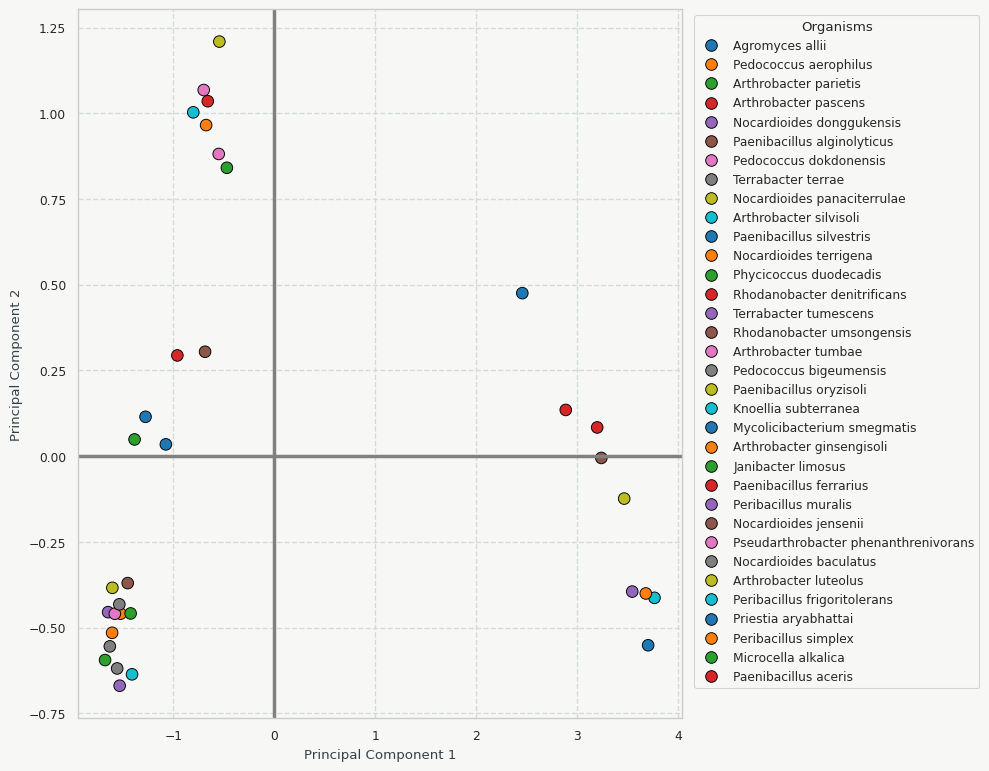

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Assume df is your dataframe: rows = organisms, columns = CAI weights, index = organism names
df = arabidopsis_cai_weights
# PCA transformation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.values)

# Prepare DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'organism': df.index
})

# Color definitions
bg_color = '#f7f8f5'

sns.set(style="whitegrid", context="paper") 
plt.figure(figsize=(10,8))
ax = plt.gca()

# Set unified background for plot and legend
plt.gcf().patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Draw grid
ax.grid(True, which='both', color='#d4dadb', linestyle='--', linewidth=1)

# Draw bold x and y axes lines (centered at 0)
ax.axhline(0, color='grey', linewidth=2.5)  # bold y=0 line
ax.axvline(0, color='grey', linewidth=2.5)  # bold x=0 line

sns.scatterplot(
    data=pca_df,
    x='PC1', 
    y='PC2',
    s=70,
    edgecolor='black',
    hue='organism',
    palette='tab10',
    legend='full'
)

plt.xlabel("Principal Component 1", color='#324148')
plt.ylabel("Principal Component 2", color='#324148')
# plt.title("PCA of CAI Weights Across Organisms", fontweight='bold', fontsize=13 ,color='#324148')

# Customize legend to use same background
leg = plt.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    title='Organisms',
    frameon=True
)
frame = leg.get_frame()
frame.set_facecolor(bg_color)
frame.set_edgecolor('#cccccc')

plt.tight_layout()
plt.show()



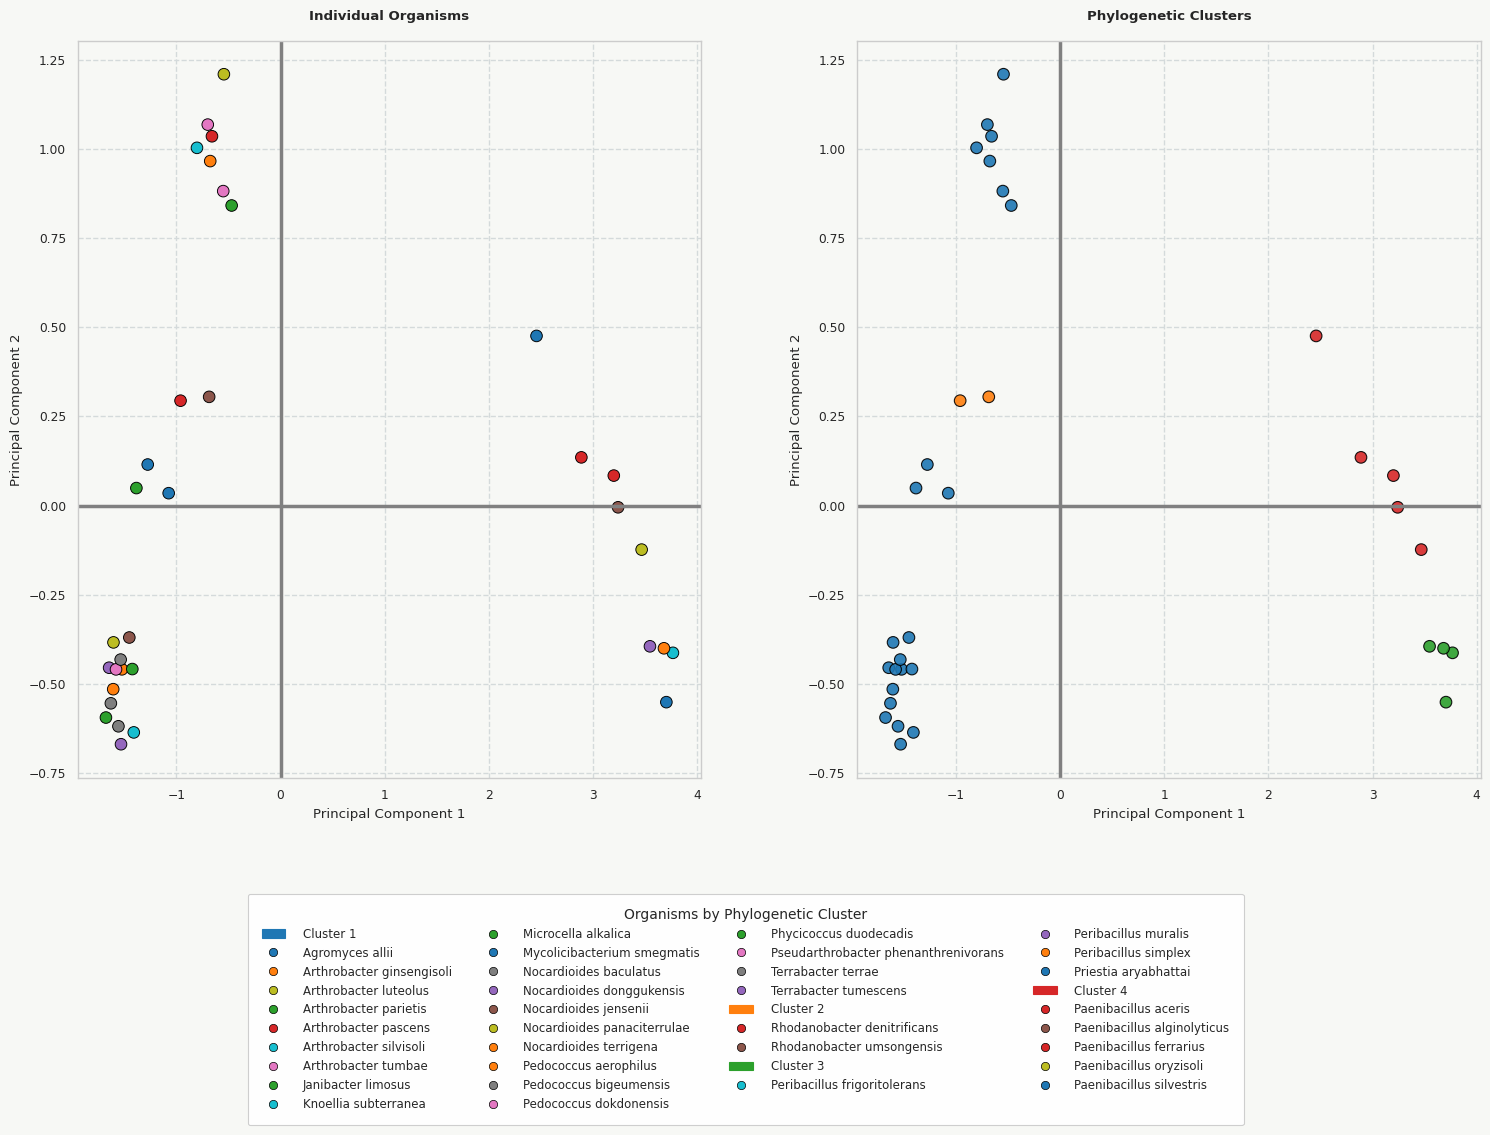

Cluster composition:
Cluster 1: Agromyces allii, Pedococcus aerophilus, Arthrobacter parietis, Arthrobacter pascens, Nocardioides donggukensis, Pedococcus dokdonensis, Terrabacter terrae, Nocardioides panaciterrulae, Arthrobacter silvisoli, Nocardioides terrigena, Phycicoccus duodecadis, Terrabacter tumescens, Arthrobacter tumbae, Pedococcus bigeumensis, Knoellia subterranea, Mycolicibacterium smegmatis, Arthrobacter ginsengisoli, Janibacter limosus, Nocardioides jensenii, Pseudarthrobacter phenanthrenivorans, Nocardioides baculatus, Arthrobacter luteolus, Microcella alkalica
Cluster 2: Rhodanobacter denitrificans, Rhodanobacter umsongensis
Cluster 3: Peribacillus muralis, Peribacillus frigoritolerans, Priestia aryabhattai, Peribacillus simplex
Cluster 4: Paenibacillus alginolyticus, Paenibacillus silvestris, Paenibacillus oryzisoli, Paenibacillus ferrarius, Paenibacillus aceris


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Assume: df, cluster_lables, new_index
cluster_series = pd.Series(cluster_lables, index=new_index, name="phylo_cluster")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.values)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'organism': df.index
})
pca_df = pca_df.join(cluster_series, on='organism')

# Colors
n_clusters = len(pca_df['phylo_cluster'].unique())
base_palette = sns.color_palette('tab10', n_clusters)
organism_colors = sns.color_palette('tab10', len(pca_df))

cluster_colors = {}
for cluster_id in sorted(pca_df['phylo_cluster'].unique()):
    palette_idx = cluster_id - 1
    cluster_colors[cluster_id] = tuple(np.array(base_palette[palette_idx]))

bg_color = '#f7f8f5'

fig = plt.figure(figsize=(15, 11))  # Square proportions matching your reference

# === Single row of plots ===
ax1 = plt.subplot(1, 2, 1)
sns.set(style="whitegrid", context="paper")
fig.patch.set_facecolor(bg_color)
ax1.set_facecolor(bg_color)
ax1.grid(True, which='both', color='#d4dadb', linestyle='--', linewidth=1)
ax1.axhline(0, color='grey', linewidth=2.5)
ax1.axvline(0, color='grey', linewidth=2.5)

sns.scatterplot(data=pca_df, x='PC1', y='PC2', s=70, edgecolor='black',
                hue='organism', palette='tab10', legend=False, ax=ax1)
ax1.set_title("Individual Organisms", fontweight='bold', pad=15)
ax1.set_xlabel("Principal Component 1")
ax1.set_ylabel("Principal Component 2")

ax2 = plt.subplot(1, 2, 2)
ax2.set_facecolor(bg_color)
ax2.grid(True, which='both', color='#d4dadb', linestyle='--', linewidth=1)
ax2.axhline(0, color='grey', linewidth=2.5)
ax2.axvline(0, color='grey', linewidth=2.5)

cluster_colors_list = [cluster_colors[row['phylo_cluster']] for _, row in pca_df.iterrows()]
ax2.scatter(pca_df['PC1'], pca_df['PC2'], c=cluster_colors_list, 
            s=70, edgecolor='black', alpha=0.9)
ax2.set_title("Phylogenetic Clusters", fontweight='bold', pad=15)
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")

# === BOTTOM COLUMNAR LEGEND ===
legend_handles_col = {cid: [] for cid in sorted(pca_df['phylo_cluster'].unique())}
legend_labels_col = {cid: [] for cid in sorted(pca_df['phylo_cluster'].unique())}

for cluster_id in sorted(pca_df['phylo_cluster'].unique()):
    legend_handles_col[cluster_id].append(mpatches.Patch(color=cluster_colors[cluster_id]))
    legend_handles_col[cluster_id].append(Line2D([0], [0], color='none'))
    legend_labels_col[cluster_id].append(f'Cluster {cluster_id}')
    legend_labels_col[cluster_id].append('')
    
    cluster_orgs = pca_df[pca_df['phylo_cluster'] == cluster_id]['organism'].tolist()
    for organism in cluster_orgs:
        i = list(pca_df['organism']).index(organism)
        color = organism_colors[i % len(organism_colors)]
        handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                        markersize=6, markeredgecolor='black', markeredgewidth=0.5)
        legend_handles_col[cluster_id].append(handle)
        legend_labels_col[cluster_id].append(organism)

# MODIFIED LEGEND: Each cluster in its own column
handles_per_cluster = []
labels_per_cluster = []

for cluster_id in sorted(pca_df['phylo_cluster'].unique()):
    handles_per_cluster.append(mpatches.Patch(color=cluster_colors[cluster_id]))
    labels_per_cluster.append(f'Cluster {cluster_id}')
    
    cluster_orgs = sorted(pca_df[pca_df['phylo_cluster'] == cluster_id]['organism'].tolist())
    for organism in cluster_orgs:
        i = list(pca_df['organism']).index(organism)
        color = organism_colors[i % len(organism_colors)]
        handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                        markersize=6, markeredgecolor='black', markeredgewidth=0.5)
        handles_per_cluster.append(handle)
        labels_per_cluster.append(organism)

central_legend = fig.legend(handles_per_cluster, labels_per_cluster, 
                           bbox_to_anchor=(0.5, 0.08), loc='upper center',
                           fontsize=8.5, frameon=True, framealpha=0.95, 
                           ncol=n_clusters,  # One column per cluster
                           columnspacing=2.5,
                           handletextpad=1.5,
                           borderpad=1.2,
                           title="Organisms by Phylogenetic Cluster",
                           title_fontsize=10)


plt.tight_layout()
plt.subplots_adjust(bottom=0.18, top=0.85, wspace=0.25)  # Optimized for square proportions
plt.show()

print("Cluster composition:")
for cluster_id in sorted(pca_df['phylo_cluster'].unique()):
    members = pca_df[pca_df['phylo_cluster'] == cluster_id]['organism'].tolist()
    print(f"Cluster {cluster_id}: {', '.join(members)}")


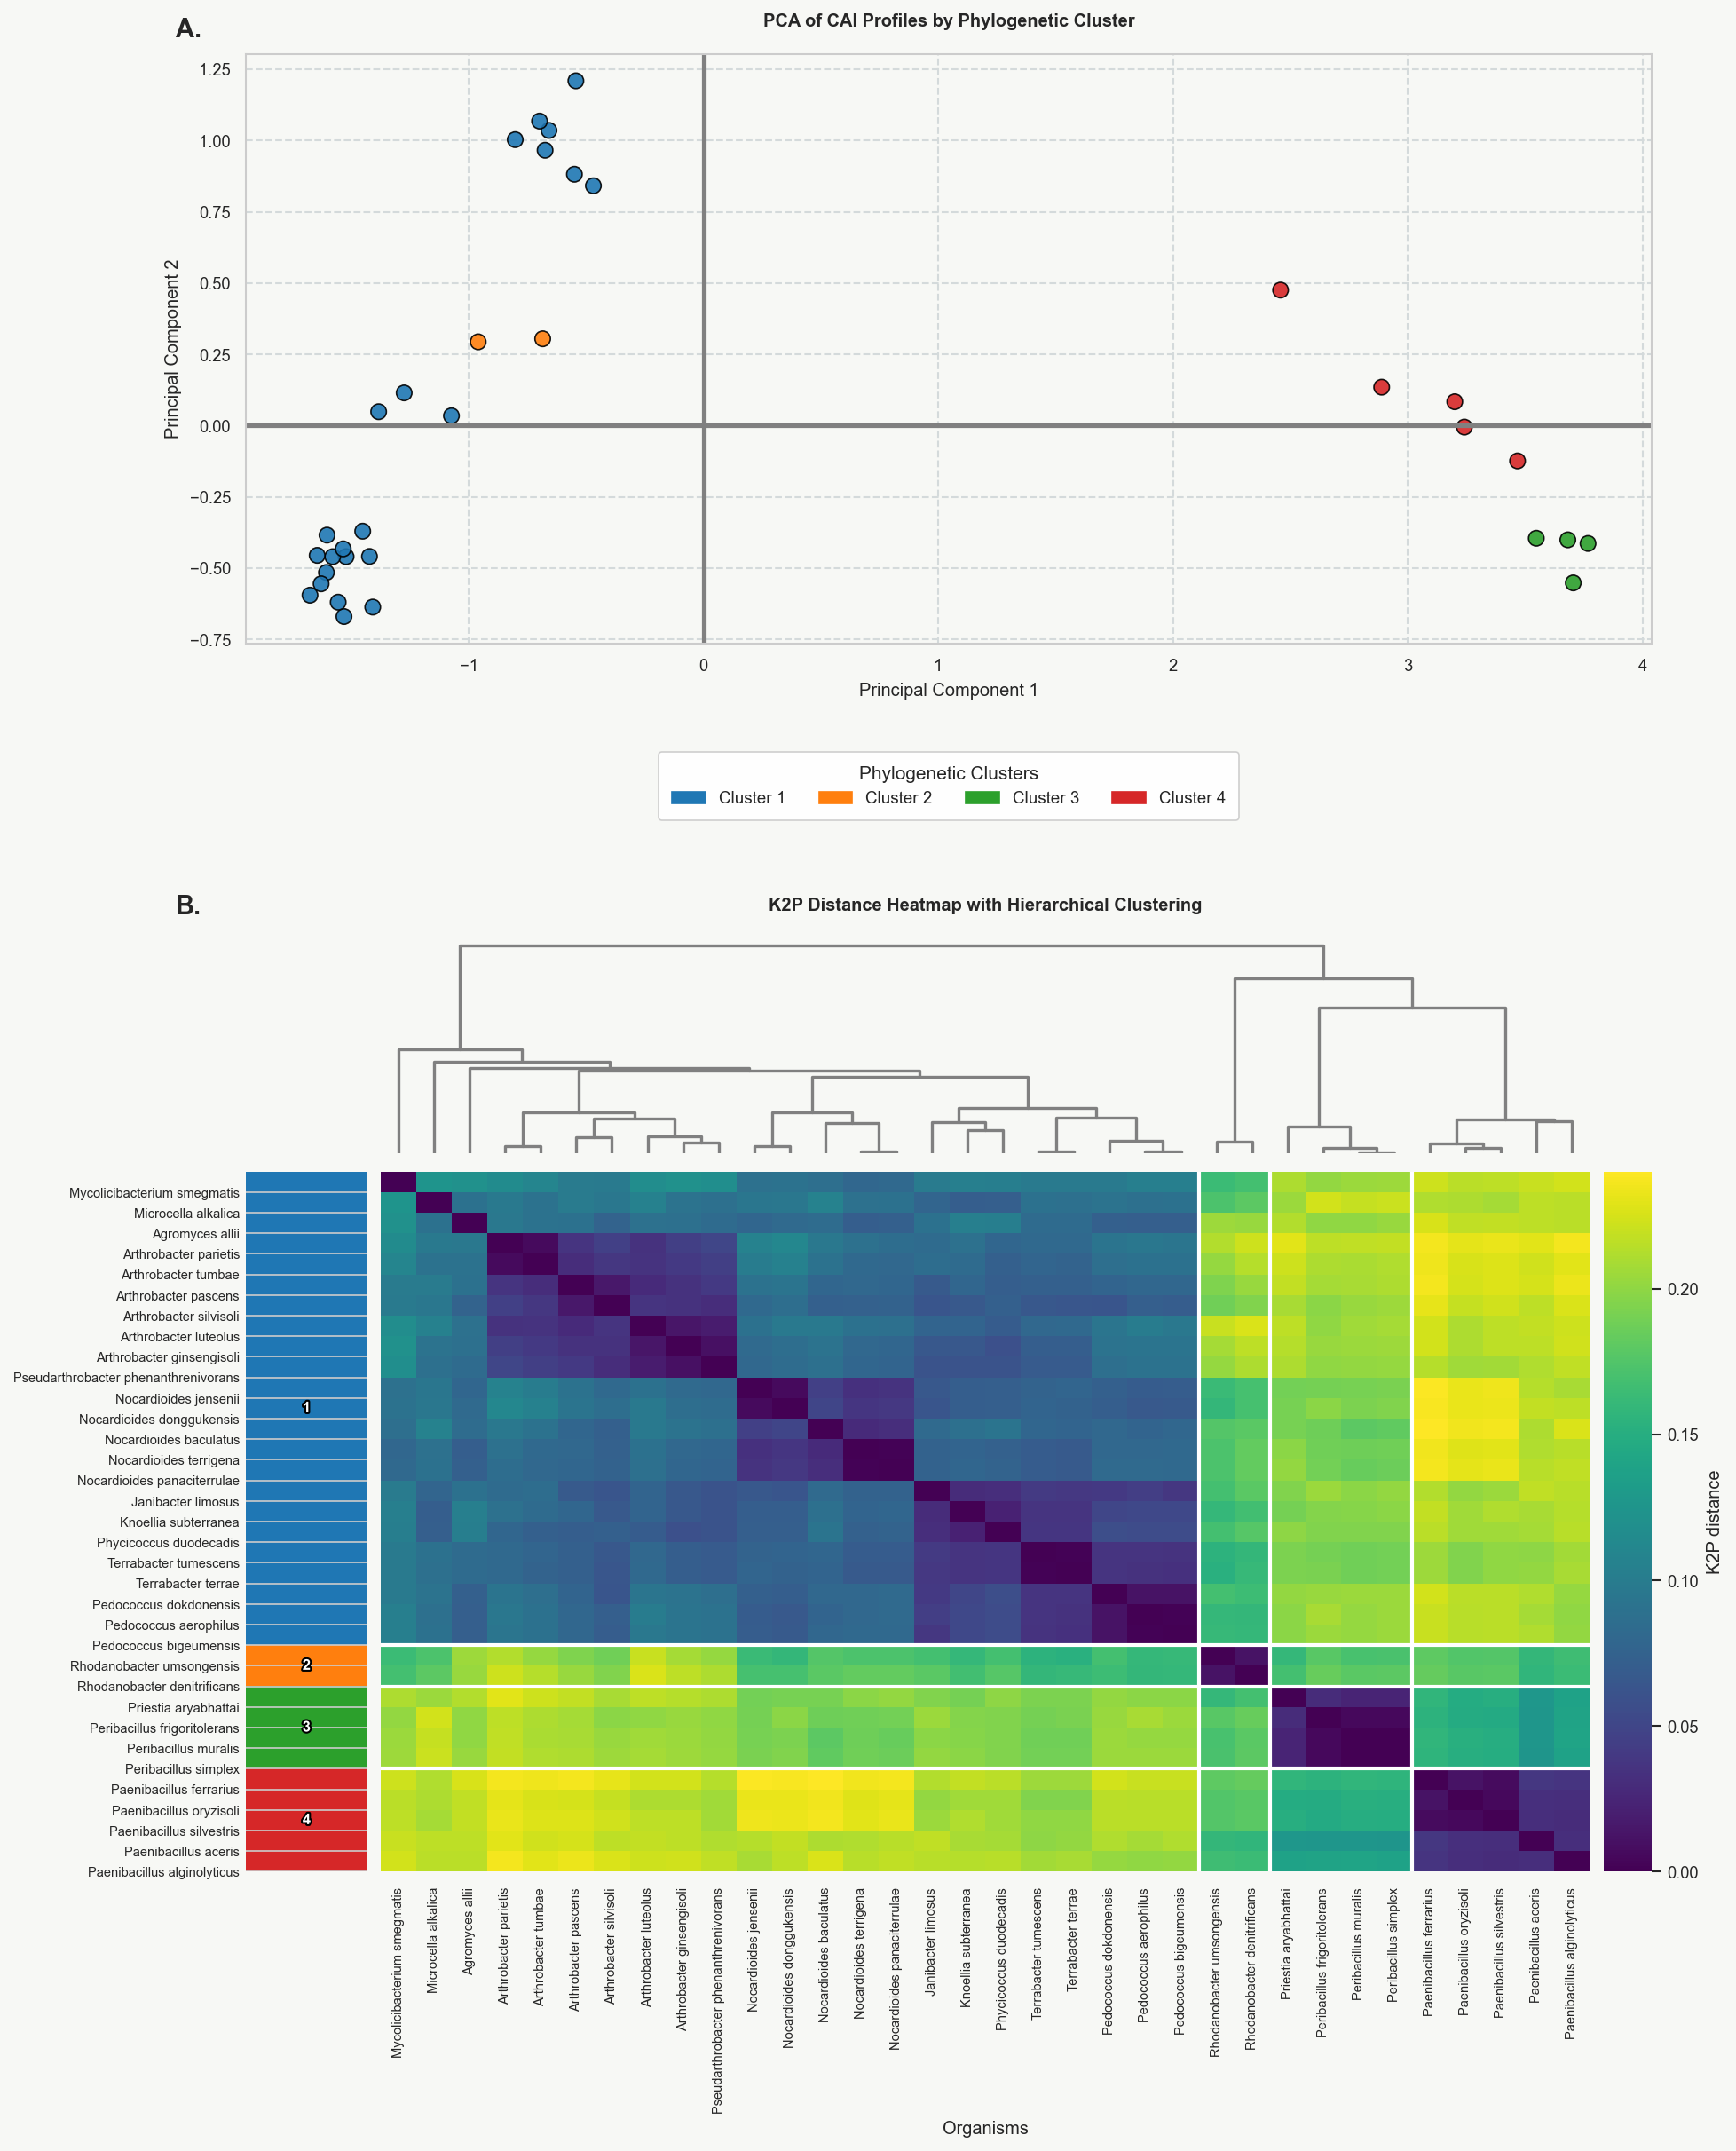

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.patches as mpatches
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from itertools import groupby
import os

# =========================================================
# REQUIRED INPUTS:
# df              -> CAI dataframe, rows = organisms, columns = CAI features/codons
# dist_df         -> square symmetric K2P distance dataframe, indexed by organism
# cluster_lables  -> chosen flat cluster labels
# new_index       -> organism names aligned with cluster_lables
# =========================================================

# -----------------------------
# Style
# -----------------------------
sns.set(style="whitegrid", context="paper")
bg_color = '#f7f8f5'
grid_color = '#d4dadb'

# -----------------------------
# Align cluster labels to df.index
# -----------------------------
cluster_series = pd.Series(cluster_lables, index=new_index, name="phylo_cluster")
cluster_series = cluster_series.reindex(df.index)

if cluster_series.isna().any():
    missing = cluster_series[cluster_series.isna()].index.tolist()
    raise ValueError(f"Missing cluster labels for organisms: {missing}")

dist_df = dist_df.loc[df.index, df.index]

# -----------------------------
# PCA on CAI profiles
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.values)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'organism': df.index
})
pca_df = pca_df.join(cluster_series, on='organism')

# -----------------------------
# Colors
# -----------------------------
cluster_ids = sorted(pca_df['phylo_cluster'].unique())
n_clusters = len(cluster_ids)

base_palette = sns.color_palette('tab10', n_clusters)
cluster_colors = {cid: base_palette[i] for i, cid in enumerate(cluster_ids)}

# Shared legend handles (used in middle legend row)
legend_handles = [
    mpatches.Patch(color=cluster_colors[cid], label=f'Cluster {cid}')
    for cid in cluster_ids
]

# -----------------------------
# Hierarchical clustering on K2P distances
# -----------------------------
condensed_dist = squareform(dist_df.values, checks=False)
Z = linkage(condensed_dist, method='average')

ddata = dendrogram(Z, no_plot=True)
leaf_order = ddata["leaves"]

ordered_names = dist_df.index[leaf_order]
ordered_dist = dist_df.loc[ordered_names, ordered_names]
ordered_cluster_ids = cluster_series.loc[ordered_names]
row_colors = [cluster_colors[c] for c in ordered_cluster_ids]

# Contiguous cluster blocks in dendrogram order (for labels and boundary lines)
strip_blocks = []
pos = 0
for cid, grp in groupby(ordered_cluster_ids.values):
    count = sum(1 for _ in grp)
    strip_blocks.append((cid, pos, pos + count - 1))
    pos += count

def scipy_x_to_heatmap_x(x):
    return (x - 5.0) / 10.0 + 0.5

# -----------------------------
# Figure layout
# row 0 -> PCA (A.)
# row 1 -> shared cluster legend
# row 2 -> dendrogram + heatmap (B.)
# -----------------------------
fig = plt.figure(figsize=(12, 15), facecolor=bg_color)
gs = GridSpec(
    3, 1,
    figure=fig,
    height_ratios=[1.0, 0.09, 1.6],
    hspace=0.22
)

# =========================================================
# TOP (A.): PCA by phylogenetic cluster
# =========================================================
ax_pca = fig.add_subplot(gs[0, 0])
ax_pca.set_facecolor(bg_color)
ax_pca.grid(True, which='both', color=grid_color, linestyle='--', linewidth=1)
ax_pca.axhline(0, color='grey', linewidth=2.5)
ax_pca.axvline(0, color='grey', linewidth=2.5)

cluster_colors_list = [cluster_colors[row['phylo_cluster']] for _, row in pca_df.iterrows()]
ax_pca.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=cluster_colors_list,
    s=70,
    edgecolor='black',
    alpha=0.9
)

ax_pca.set_title("PCA of CAI Profiles by Phylogenetic Cluster", fontweight='bold', pad=15)
ax_pca.set_xlabel(f"Principal Component 1")
ax_pca.set_ylabel(f"Principal Component 2")
ax_pca.text(-0.05, 1.02, 'A.', transform=ax_pca.transAxes,
            fontsize=14, fontweight='bold', va='bottom', ha='left', clip_on=False)

# =========================================================
# MIDDLE: Shared cluster color legend
# =========================================================
ax_leg = fig.add_subplot(gs[1, 0])
ax_leg.axis('off')
ax_leg.set_facecolor(bg_color)
leg = ax_leg.legend(
    handles=legend_handles,
    loc='center',
    ncol=n_clusters,
    fontsize=9,
    frameon=True,
    framealpha=0.95,
    title="Phylogenetic Clusters",
    title_fontsize=10,
    columnspacing=2.0,
    handletextpad=0.8,
    borderpad=0.8
)
leg.get_frame().set_edgecolor('#cccccc')

# =========================================================
# BOTTOM (B.): dendrogram + cluster strip + heatmap + colorbar
# =========================================================
# Invisible outer axes over the full bottom row — used only for the B. label
ax_b_outer = fig.add_subplot(gs[2, 0])
ax_b_outer.axis('off')
ax_b_outer.set_facecolor('none')
ax_b_outer.text(-0.05, 1.01, 'B.', transform=ax_b_outer.transAxes,
                fontsize=14, fontweight='bold', va='bottom', ha='left', clip_on=False)

bottom = GridSpecFromSubplotSpec(
    2, 3,
    subplot_spec=gs[2, 0],
    height_ratios=[0.32, 1.0],
    width_ratios=[0.10, 1.0, 0.04],
    hspace=0.04,
    wspace=0.03
)

ax_den   = fig.add_subplot(bottom[0, 1])
ax_strip = fig.add_subplot(bottom[1, 0])
ax_hm    = fig.add_subplot(bottom[1, 1])
ax_cbar  = fig.add_subplot(bottom[1, 2])

n = len(ordered_names)

# Heatmap
sns.heatmap(
    ordered_dist,
    cmap='viridis',
    ax=ax_hm,
    xticklabels=ordered_names,
    yticklabels=False,
    cbar=True,
    cbar_ax=ax_cbar,
    cbar_kws={'label': 'K2P distance'}
)
ax_hm.set_facecolor(bg_color)
ax_hm.set_xlabel("Organisms")
ax_hm.set_ylabel("")
ax_hm.tick_params(axis='x', labelrotation=90, labelsize=7)

# White separator lines at cluster boundaries
for _, start, _ in strip_blocks[1:]:
    ax_hm.axhline(start, color='white', linewidth=2.0)
    ax_hm.axvline(start, color='white', linewidth=2.0)

# Cluster strip
strip_array = np.array(row_colors).reshape(n, 1, 3)
ax_strip.imshow(strip_array, aspect='auto', origin='upper')
ax_strip.set_xticks([])
ax_strip.set_yticks(np.arange(n) + 0.5)
ax_strip.set_yticklabels(ordered_names, fontsize=7)
ax_strip.tick_params(axis='y', length=0)
ax_strip.yaxis.tick_left()
ax_strip.set_facecolor(bg_color)
for spine in ax_strip.spines.values():
    spine.set_visible(False)

# Cluster number labels centered on each contiguous block in the strip
for cid, start, end in strip_blocks:
    mid_y = (start + end) / 2.0
    ax_strip.text(0, mid_y, str(cid),
                  ha='center', va='center',
                  fontsize=8, fontweight='bold', color='white',
                  path_effects=[pe.withStroke(linewidth=2.0, foreground='black')],
                  clip_on=True)

# Custom dendrogram aligned exactly to heatmap columns
for xs, ys in zip(ddata["icoord"], ddata["dcoord"]):
    xs_new = [scipy_x_to_heatmap_x(x) for x in xs]
    ax_den.plot(xs_new, ys, color='grey', linewidth=1.6)

max_height = max(max(y) for y in ddata["dcoord"])
ax_den.set_xlim(0, n)
ax_den.set_ylim(0, max_height * 1.08)
ax_den.set_xticks([])
ax_den.set_yticks([])
ax_den.set_facecolor(bg_color)
ax_den.set_title("K2P Distance Heatmap with Hierarchical Clustering", fontweight='bold', pad=10)
ax_den.margins(x=0, y=0.02)
for spine in ax_den.spines.values():
    spine.set_visible(False)

# -----------------------------
# Final layout
# -----------------------------
fig.subplots_adjust(
    left=0.08,
    right=0.96,
    top=0.96,
    bottom=0.05
)

plt.show()

# -----------------------------
# Cluster composition output
# -----------------------------
print("Cluster composition:")
for cluster_id in cluster_ids:
    members = pca_df[pca_df['phylo_cluster'] == cluster_id]['organism'].tolist()
    print(f"Cluster {cluster_id}: {', '.join(members)}")

output_path = os.path.join(os.getcwd(), "combined_pca_k2p_clustering.svg")
fig.savefig(output_path, format='svg', bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"Figure saved to: {output_path}")


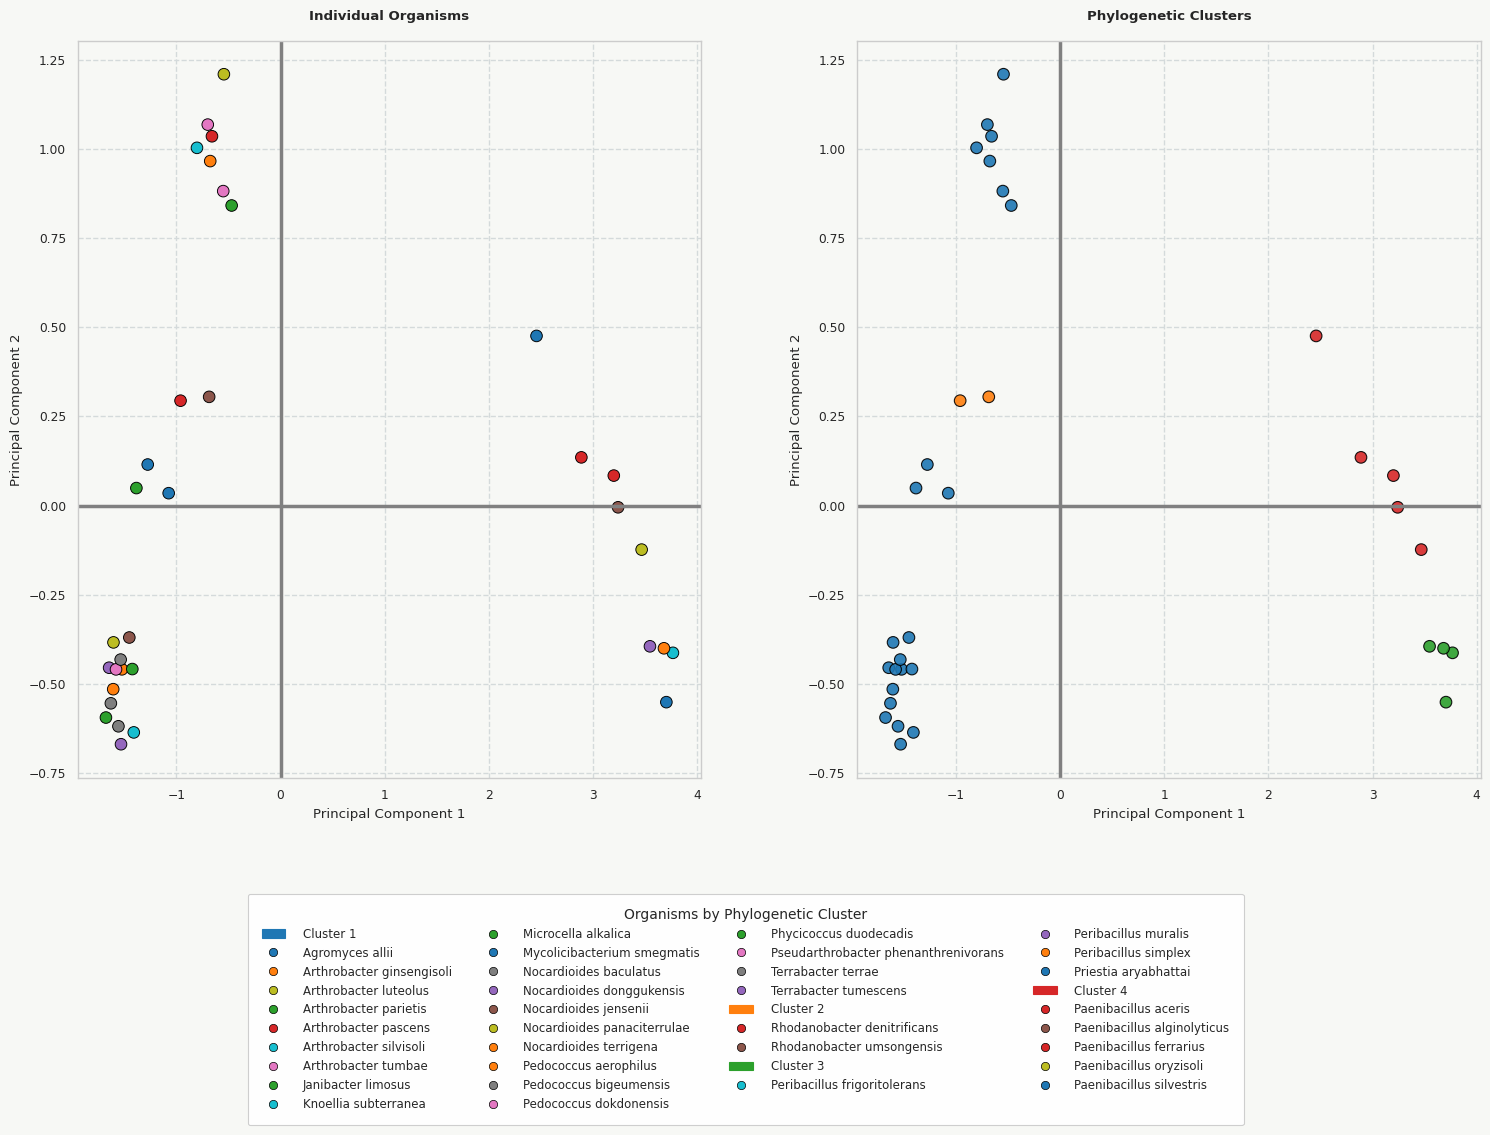

Cluster composition:
Cluster 1: Agromyces allii, Pedococcus aerophilus, Arthrobacter parietis, Arthrobacter pascens, Nocardioides donggukensis, Pedococcus dokdonensis, Terrabacter terrae, Nocardioides panaciterrulae, Arthrobacter silvisoli, Nocardioides terrigena, Phycicoccus duodecadis, Terrabacter tumescens, Arthrobacter tumbae, Pedococcus bigeumensis, Knoellia subterranea, Mycolicibacterium smegmatis, Arthrobacter ginsengisoli, Janibacter limosus, Nocardioides jensenii, Pseudarthrobacter phenanthrenivorans, Nocardioides baculatus, Arthrobacter luteolus, Microcella alkalica
Cluster 2: Rhodanobacter denitrificans, Rhodanobacter umsongensis
Cluster 3: Peribacillus muralis, Peribacillus frigoritolerans, Priestia aryabhattai, Peribacillus simplex
Cluster 4: Paenibacillus alginolyticus, Paenibacillus silvestris, Paenibacillus oryzisoli, Paenibacillus ferrarius, Paenibacillus aceris


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Assume: df, cluster_lables, new_index
cluster_series = pd.Series(cluster_lables, index=new_index, name="phylo_cluster")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.values)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'organism': df.index
})
pca_df = pca_df.join(cluster_series, on='organism')

# Colors
n_clusters = len(pca_df['phylo_cluster'].unique())
base_palette = sns.color_palette('tab10', n_clusters)
organism_colors = sns.color_palette('tab10', len(pca_df))

cluster_colors = {}
for cluster_id in sorted(pca_df['phylo_cluster'].unique()):
    palette_idx = cluster_id - 1
    cluster_colors[cluster_id] = tuple(np.array(base_palette[palette_idx]))

bg_color = '#f7f8f5'

fig = plt.figure(figsize=(15, 11))  # Square proportions matching your reference

# === Single row of plots ===
ax1 = plt.subplot(1, 2, 1)
sns.set(style="whitegrid", context="paper")
fig.patch.set_facecolor(bg_color)
ax1.set_facecolor(bg_color)
ax1.grid(True, which='both', color='#d4dadb', linestyle='--', linewidth=1)
ax1.axhline(0, color='grey', linewidth=2.5)
ax1.axvline(0, color='grey', linewidth=2.5)

sns.scatterplot(data=pca_df, x='PC1', y='PC2', s=70, edgecolor='black',
                hue='organism', palette='tab10', legend=False, ax=ax1)
ax1.set_title("Individual Organisms", fontweight='bold', pad=15)
ax1.set_xlabel("Principal Component 1")
ax1.set_ylabel("Principal Component 2")

ax2 = plt.subplot(1, 2, 2)
ax2.set_facecolor(bg_color)
ax2.grid(True, which='both', color='#d4dadb', linestyle='--', linewidth=1)
ax2.axhline(0, color='grey', linewidth=2.5)
ax2.axvline(0, color='grey', linewidth=2.5)

cluster_colors_list = [cluster_colors[row['phylo_cluster']] for _, row in pca_df.iterrows()]
ax2.scatter(pca_df['PC1'], pca_df['PC2'], c=cluster_colors_list, 
            s=70, edgecolor='black', alpha=0.9)
ax2.set_title("Phylogenetic Clusters", fontweight='bold', pad=15)
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")

# === BOTTOM COLUMNAR LEGEND ===
legend_handles_col = {cid: [] for cid in sorted(pca_df['phylo_cluster'].unique())}
legend_labels_col = {cid: [] for cid in sorted(pca_df['phylo_cluster'].unique())}

for cluster_id in sorted(pca_df['phylo_cluster'].unique()):
    legend_handles_col[cluster_id].append(mpatches.Patch(color=cluster_colors[cluster_id]))
    legend_handles_col[cluster_id].append(Line2D([0], [0], color='none'))
    legend_labels_col[cluster_id].append(f'Cluster {cluster_id}')
    legend_labels_col[cluster_id].append('')
    
    cluster_orgs = pca_df[pca_df['phylo_cluster'] == cluster_id]['organism'].tolist()
    for organism in cluster_orgs:
        i = list(pca_df['organism']).index(organism)
        color = organism_colors[i % len(organism_colors)]
        handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                        markersize=6, markeredgecolor='black', markeredgewidth=0.5)
        legend_handles_col[cluster_id].append(handle)
        legend_labels_col[cluster_id].append(organism)

# MODIFIED LEGEND: Each cluster in its own column
handles_per_cluster = []
labels_per_cluster = []

for cluster_id in sorted(pca_df['phylo_cluster'].unique()):
    handles_per_cluster.append(mpatches.Patch(color=cluster_colors[cluster_id]))
    labels_per_cluster.append(f'Cluster {cluster_id}')
    
    cluster_orgs = sorted(pca_df[pca_df['phylo_cluster'] == cluster_id]['organism'].tolist())
    for organism in cluster_orgs:
        i = list(pca_df['organism']).index(organism)
        color = organism_colors[i % len(organism_colors)]
        handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                        markersize=6, markeredgecolor='black', markeredgewidth=0.5)
        handles_per_cluster.append(handle)
        labels_per_cluster.append(organism)

central_legend = fig.legend(handles_per_cluster, labels_per_cluster, 
                           bbox_to_anchor=(0.5, 0.08), loc='upper center',
                           fontsize=8.5, frameon=True, framealpha=0.95, 
                           ncol=n_clusters,  # One column per cluster
                           columnspacing=2.5,
                           handletextpad=1.5,
                           borderpad=1.2,
                           title="Organisms by Phylogenetic Cluster",
                           title_fontsize=10)


plt.tight_layout()
plt.subplots_adjust(bottom=0.18, top=0.85, wspace=0.25)  # Optimized for square proportions
plt.show()

print("Cluster composition:")
for cluster_id in sorted(pca_df['phylo_cluster'].unique()):
    members = pca_df[pca_df['phylo_cluster'] == cluster_id]['organism'].tolist()
    print(f"Cluster {cluster_id}: {', '.join(members)}")


### pairwise

In [19]:
pairwise_output_path = os.path.join(base_output_path, "pairwise")
for optimization_method in [
    "single_codon_diff", 
    # "single_codon_ratio",
    # "zscore_bulk_aa_diff",
    # "zscore_bulk_aa_ratio",
    # single_wanted_organism",
]:
    run_configurations = []
    for wanted_organism in organisms_list:
        for unwanted_organism in organisms_list:
            if wanted_organism == unwanted_organism:
                continue
            run_configurations.append((wanted_organism, unwanted_organism, optimization_method)) 

    inputs = [(
        run_configration, 
        generate_testing_data(
            orf_optimization_method = run_configration[2],
            orf_optimization_cub_index = "CAI",
            wanted_hosts = [run_configration[0]],
            unwanted_hosts = [run_configration[1]], 
            genome_path = genomes_gb_path,
            sequence_file_path = zorA_file_path,
            output_path = pairwise_output_path,
        )) for run_configration in run_configurations]

    print(f"Total number of records is: {len(inputs)}")
    batch_size = 50
    
    for batch_index, batch_start_index in enumerate(range(0, len(inputs), batch_size)):
        inputs_batch = inputs[batch_start_index: batch_start_index+batch_size]
        inputs_db = db.from_sequence(inputs_batch)
        results_db = inputs_db.map(run_modules_for_configuration)
        batch_file_path = os.path.join(pairwise_output_path, optimization_method, f"batch-{batch_index}")
        batch_file_path = batch_file_path + "-debug"
        results_db.map(json.dumps).to_textfiles(os.path.join(batch_file_path, '*.json'))
        os.mknod(os.path.join(batch_file_path, "done"))


Total number of records is: 1122
29600


Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB


### One vs. All

In [ ]:
single_wanted_output_path = os.path.join(base_output_path, "one_vs_all")
for optimization_method in [
    "single_codon_diff", 
    # "single_codon_ratio",
    # "zscore_bulk_aa_diff",
    # "zscore_bulk_aa_ratio",
    # "single_wanted_organism",
]:
    run_configurations = []
    for wanted_organism in organisms_list:
        unwanted_organisms = set(organisms_list)
        unwanted_organisms.remove(wanted_organism)
        unwanted_organisms = list(unwanted_organisms)
        run_configurations.append([wanted_organism, unwanted_organisms, optimization_method]) 

    inputs = [(
        run_configuration, 
        generate_testing_data(
            orf_optimization_method = run_configuration[2],
            orf_optimization_cub_index = "CAI",
            wanted_hosts = [run_configuration[0]],
            unwanted_hosts = run_configuration[1], 
            genome_path = genomes_gb_path,
            sequence_file_path = zorA_file_path,
            output_path = single_wanted_output_path,
        )) for run_configuration in run_configurations]

    
    print(f"Total number of records is: {len(inputs)}")
    batch_size = 50
    
    for batch_index, batch_start_index in enumerate(range(0, len(inputs), batch_size)):
        batch_file_path = os.path.join(single_wanted_output_path, optimization_method, f"batch-{batch_index}")
        batch_file_path = batch_file_path + "-debug"
        inputs_batch = inputs[batch_start_index: batch_start_index+batch_size]
        inputs_db = db.from_sequence(inputs_batch)
        results_db = inputs_db.map(run_modules_for_configuration)
        results_db.map(json.dumps).to_textfiles(os.path.join(batch_file_path, '*.json'))
        os.mknod(os.path.join(batch_file_path, "done"))

    # Local debugging
        
    # inputs = [(
    #     run_configuration, 
    #     generate_testing_data(
    #         orf_optimization_method = run_configuration[2],
    #         orf_optimization_cub_index = "CAI",
    #         wanted_hosts = [run_configuration[0]],
    #         unwanted_hosts = run_configuration[1], 
    #         genome_path = genomes_gb_path,
    #         sequence_file_path = zorA_file_path,
    #         output_path = single_wanted_output_path,
    #     )) for run_configuration in run_configurations[:1]]

    
    # raw_result = run_modules_for_configuration(inputs[0])


Total number of records is: 34


Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, ini

Total number of records is: 34


Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, ini

### Cluster vs. All

In [ ]:
wanted_cluster_output_path = os.path.join(base_output_path, "cluster_vs_all")
for optimization_method in [
    "single_codon_diff", 
    "single_codon_ratio",
    "zscore_bulk_aa_diff",
    "zscore_bulk_aa_ratio",
    "single_wanted_organism",
]:
    run_configurations = []
    for organisms_cluster in organism_clusters:
        wanted_organisms = [os.path.join(genomes_gb_path, wanted_organism)+".gbff" for wanted_organism in organisms_cluster]
        unwanted_organisms = set(organisms_list)
        unwanted_organisms = unwanted_organisms - set(wanted_organisms)
        unwanted_organisms = list(unwanted_organisms)
        assert len(wanted_organisms) + len(unwanted_organisms) == 34
        
        if optimization_method == "single_wanted_organism":
            permutations = [wanted_organisms[-i:] + wanted_organisms[:-i] for i in range(len(wanted_organisms))]
        else:
            permutations = [wanted_organisms]
        for wanted_organisms_permutation in permutations:
            run_configurations.append([wanted_organisms_permutation, unwanted_organisms, optimization_method]) 

    inputs = [(
        run_configuration, 
        generate_testing_data(
            orf_optimization_method = run_configuration[2],
            orf_optimization_cub_index = "CAI",
            wanted_hosts = run_configuration[0],
            unwanted_hosts = run_configuration[1], 
            genome_path = genomes_gb_path,
            sequence_file_path = zorA_file_path,
            output_path = wanted_cluster_output_path,
        )) for run_configuration in run_configurations]
    
    print(f"Total number of records is: {len(inputs)}")
    batch_size = 50
    
    # for batch_index, batch_start_index in enumerate(range(0, len(inputs), batch_size)):
    for batch_index, batch_start_index in enumerate(range(0, 1)):
        batch_file_path = os.path.join(wanted_cluster_output_path, optimization_method, f"batch-{batch_index}")
        batch_file_path = batch_file_path + "-debug"
        inputs_batch = inputs[batch_start_index: batch_start_index+batch_size]
        inputs_db = db.from_sequence(inputs_batch)
        results_db = inputs_db.map(run_modules_for_configuration)
        results_db.map(json.dumps).to_textfiles(os.path.join(batch_file_path, '*.json'))
        os.mknod(os.path.join(batch_file_path, "done"))


Total number of records is: 4


/tamir2/moranb/microbiome/Igem_TAU_2021/venv/lib/python3.9/site-packages/jupyter_server/base/handlers.py:599: UserWarning: The Tornado web application does not have an 'identity_provider' defined in its settings. In future releases of jupyter_server, this will be a required key for all subclasses of `JupyterHandler`. For an example, see the jupyter_server source code for how to add an identity provider to the tornado settings: https://github.com/jupyter-server/jupyter_server/blob/v2.0.0/jupyter_server/serverapp.py#L242
  if type(self.identity_provider) is IdentityProvider and mod_obj.__name__ != __name__:
2026-03-24 12:27:04,541 - tornado.application - ERROR - Uncaught exception GET /proxy/33500/132.66.112.146/status (132.66.112.113)
HTTPServerRequest(protocol='http', host='localhost:12435', method='GET', uri='/proxy/33500/132.66.112.146/status', version='HTTP/1.1', remote_ip='132.66.112.113')
Traceback (most recent call last):
  File "/tamir2/moranb/microbiome/Igem_TAU_2021/venv/lib/p

Total number of records is: 4
Total number of records is: 4
Total number of records is: 4
Total number of records is: 34


Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, ini

### Different host set sizes

In [ ]:
different_sizes_output_path = os.path.join(base_output_path, "different_set_sizes")

# The sizes of the wanted/unwanted groups
group_sizes = [1, 2, 4, 8, 16]
num_repeats = 10

run_configurations = []
for size in group_sizes:
    for rep in range(num_repeats):

        # Need 2 × size distinct hosts
        if len(organisms_list) < 2 * size:
            raise ValueError(f"Not enough organisms to sample size={size} groups")

        # Randomly sample wanted + unwanted together to avoid overlap
        sampled = random.sample(organisms_list, 2 * size)

        wanted = sampled[:size]
        unwanted = sampled[size:]
        run_configurations.append([wanted, unwanted])

for optimization_method in [
    "single_codon_diff", 
    "single_codon_ratio",
    "zscore_bulk_aa_diff",
    "zscore_bulk_aa_ratio",
    # "single_wanted_organism",
]:
    inputs = []
    for wanted_set, unwanted_set in run_configurations:
        generated = generate_testing_data(
            orf_optimization_method=optimization_method,
            orf_optimization_cub_index="CAI",
            wanted_hosts=wanted_set,
            unwanted_hosts=unwanted_set,
            genome_path=genomes_gb_path,
            sequence_file_path=zorA_file_path,
            output_path=different_sizes_output_path,
        )
        inputs.append(([wanted_set, unwanted_set, method], generated))

    print(f"Total number of records is: {len(inputs)}")
    batch_size = 20
    for batch_index, batch_start_index in enumerate(range(0, len(inputs), batch_size)):
        batch_file_path = os.path.join(different_sizes_output_path, optimization_method, f"batch-{batch_index}")
        batch_file_path = batch_file_path + "-debug"
        inputs_batch = inputs[batch_start_index: batch_start_index+batch_size]
        inputs_db = db.from_sequence(inputs_batch)
        results_db = inputs_db.map(run_modules_for_configuration)
        results_db.map(json.dumps).to_textfiles(os.path.join(batch_file_path, '*.json'))
        os.mknod(os.path.join(batch_file_path, "done"))


Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB


Total number of records is: 50


Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, ini

Total number of records is: 50


Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, ini

Total number of records is: 50


Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, ini

Total number of records is: 50


Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, initializing it to select=1:ncpus=4:mem=7630MB
Resource specification for PBS not set, ini

### Liyam's Legacy Analysis code 

####  Evolutionary distance and model performance

In [ ]:
# final_tested_org = not_really_small_genome
# # func_options = ['single_codon_global', 'single_codon_local', 'zscore_hill_climbing_average', 'zscore_hill_climbing_weakest_link']
# func_options = ['single_codon_global', 'zscore_hill_climbing_average']

# spearman_dict = {}
# for translation_function in func_options:
#     opt_scores = []
#     msa_scores = []

#     tic = time.time()
#     for org1 in final_tested_org:
#         for org2 in final_tested_org:
#             # if org1.split(' ')[0] == org2.split(' ')[0]:
#             #     continue
#             if org1 == org2:
#                 continue
#             org_dict[org1]['optimized'] = True
#             org_dict[org1]['tai_profile'] = {}
#             org_dict[org1]['tai_std'] = {}
#             org_dict[org1]['tai_avg'] = {}
#             org_dict[org2]['optimized'] = False
#             org_dict[org2]['tai_profile'] = {}
#             org_dict[org2]['tai_std'] = {}
#             org_dict[org2]['tai_avg'] = {}
#             software_dict = {
#                 'sequence': cds,
#                 'tuning_param': 0.5,
#                 'organisms': {},
#                 }
#             software_dict['organisms'][org1] = org_dict[org1]
#             software_dict['organisms'][org2] = org_dict[org2]
#             inner_tic = time.time()
#             final_cds, optimization_index, weakest_score = run_orf_optimization(software_dict)
#             print('TIME: ', time.time()-inner_tic)
#             # alignment_score = pairwise2.align.globalxx(
#             #     ribosomal_dict[org1], ribosomal_dict[org2], score_only=True)
#             # aln_scores.append(alignment_score)
#             msa_score = diff_letters(ribosomal_msa_dict[org1], ribosomal_msa_dict[org2])
#             msa_scores.append(msa_score)
#             opt_scores.append(optimization_index)
#     spearman_dict[translation_function] = spearmanr(msa_scores, opt_scores, nan_policy='omit')
#     print(spearmanr(msa_scores, opt_scores, nan_policy='omit'))
#     trans_func_name = translation_function.replace('_', ' ')
#     plt.scatter(msa_scores, opt_scores, s=0.1)

#             # print(org1, org2, msa_scores, optimization_index)
#     toc = time.time()
#     print(toc-tic)

# print(spearman_dict)
# plt.legend(['single codon optimization', 'hill climbing optimization'], loc ="upper right")
# plt.title(f'Evolutionary distance and model performance')
# plt.xlabel('# Different aligned characters')
# plt.ylabel('Optimization score')
# plt.show()


#### Wanted hosts clustering

In [ ]:
from scipy.stats import spearmanr
import numpy as np
from modules import models
from sklearn.cluster import AgglomerativeClustering, KMeans

def dict_to_cluster_np_array(user_input: models.ModuleInput): #todo: make this work on tai as well
    clustering_mat = []
    opt_org_list = []
    for organism in user_input.organisms:
        if organism.is_optimized:
            cai_profile = organism.cai_profile
            clustering_mat.append(list(cai_profile.values()))
            opt_org_list.append(organism.name)
    clustering_mat=np.array(clustering_mat)
    return clustering_mat, opt_org_list


def make_distance_matrix(clustering_mat):
    n_samples = clustering_mat.shape
    n_samples = n_samples[0]
    distance_matrix = np.zeros(shape=(n_samples, n_samples))
    for i in range(n_samples):
        sample_i = clustering_mat[i,:]
        for k in range(n_samples):
            sample_k = clustering_mat[k,:]
            distance_matrix[i,k] = 1-spearmanr(sample_k, sample_i)[0] # using -1 for distance instead of similarity
    return distance_matrix


def create_n_clusters(clustering_mat, n_clus):
    dist_metric = 'precomputed'
    distance_mat = make_distance_matrix(clustering_mat)
    clustering = AgglomerativeClustering(n_clusters=n_clus,
                                         affinity=dist_metric,
                                         linkage='average').fit(distance_mat, )

    return clustering.labels_
#
# def find_best_clustering(clustering_mat, max_clus_num, c_index='dbi', c_method = 'alggomerative' ):
#     dist_metric = 'precomputed'
#     scores = []
#     clusters = []
#
#     distance_mat = make_distance_matrix(clustering_mat)
#     n_samples = distance_mat.shape
#     n_samples = n_samples[0]
#     for n_clus in range(2, min(n_samples, max_clus_num)):
#         ##### clustering options ######
#         # if c_method == 'kmeans':
#         #     clustering = KMeans(n_clusters=n_clus).fit(clustering_mat)
#         # else:
#         clustering = AgglomerativeClustering(n_clusters=n_clus,
#                                              affinity= dist_metric,
#                                              linkage='average').fit(distance_mat, )
#
#         labels = clustering.labels_
#
#         ##### cluster eval indexes ####
#         if c_index == 'dbi':
#             score = davies_bouldin_score(clustering_mat, labels)
#         else:
#             score = silhouette_score(clustering_mat, labels, metric= dist_metric)
#
#         scores.append(score)
#         clusters.append(labels)
#
#     best_score = min(scores)
#     best_clusturing = clusters[scores.index(best_score)]
#     return best_clusturing, best_score


def return_list_of_sub_microbiomes(best_clusturing: list, module_input: models.ModuleInput):
    opt_org_list = [org.name for org in module_input.organisms if org.is_optimized]
    deopt_org_list = [org.name for org in module_input.organisms if not org.is_optimized]
    c_assignment_dict = dict(zip(opt_org_list, best_clusturing))
    opt_org_clusters = list({n: [k for k in c_assignment_dict.keys() if c_assignment_dict[k] == n]
         for n in set(c_assignment_dict.values())}.values())

    inp_obj_list = []
    for c_opt_org_list in opt_org_clusters:
        opt_and_deopt = c_opt_org_list+deopt_org_list
        new_module_input = models.ModuleInput(
            organisms=[],
            sequence=module_input.sequence,
            tuning_parameter=module_input.tuning_parameter,
            clusters_count=module_input.clusters_count,
        )

        new_module_input.organisms = [module_input.organisms[i] for i in range(len(opt_org_list + deopt_org_list))
                                    if module_input.organisms[i].name in opt_and_deopt]
        inp_obj_list.append(new_module_input)
    return inp_obj_list

TypeError: run_module() missing 1 required positional argument: 'initiation_optimized_codons_num'